In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
!pip install SciencePlots

# RANDOM GRAPHS

In [167]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def create_graph(model_type, N, **kwargs):
    seed = kwargs.get('seed', None)
    if model_type == 'complete':
        return nx.complete_graph(N)
    elif model_type == 'ring':
        k = kwargs.get('k')
        return nx.watts_strogatz_graph(N, k=k, p=0.0, seed=seed)
    elif model_type == 'ER':
        p = kwargs.get('p')
        return nx.fast_gnp_random_graph(N, p=p, seed=seed)
    elif model_type == 'WS':
        k = kwargs.get('k')
        p = kwargs.get('p')
        return nx.watts_strogatz_graph(N, k=k, p=p, seed=seed)
    elif model_type == 'BA':
        m = kwargs.get('m')
        return nx.barabasi_albert_graph(N, m=m, seed=seed)

def draw_graph(G):
    fig = plt.figure(figsize=(8, 6))
    pos = nx.circular_layout(G)
    nx.draw_networkx_nodes(G, pos, node_size=200, node_color='skyblue')
    nx.draw_networkx_edges(G, pos, alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=10)
    plt.axis('off')
    plt.show()

def get_sorted_eigenvals(L):
    eigenvals = np.linalg.eigvals(L)
    eigenvals = np.sort(eigenvals)
    return eigenvals

In [168]:
N = 20

# Complete
G_comp = create_graph('complete', N)
L = nx.laplacian_matrix(G_comp).toarray().astype(float)
# A = nx.adjacency_matrix(G_comp).toarray().astype(float)

# Regular Ring (k = 4 total neighbors)
G_ring = create_graph('ring', N, k=6)
L = nx.laplacian_matrix(G_ring).toarray().astype(float)
# A = nx.adjacency_matrix(G_ring).toarray().astype(float)

# Erdős-Rényi (connection probability p = 0.2)
G_ER = create_graph('ER', N, p=0.4)
L = nx.laplacian_matrix(G_ER).toarray().astype(float)
# A = nx.adjacency_matrix(G_ER).toarray().astype(float)

# Watts-Strogatz (k = 4 total initial neighbors, rewiring probability p = 0.1)
G_WS = create_graph('WS', N, k=8, p=0.1)
L = nx.laplacian_matrix(G_WS).toarray().astype(float)
# A = nx.adjacency_matrix(G_WS).toarray().astype(float)

# Barabási-Albert (m = 2 edges per new node)
G_BA = create_graph('BA', N, m=2)
L = nx.laplacian_matrix(G_BA).toarray().astype(float)
# A = nx.adjacency_matrix(G_BA).toarray().astype(float)

# INTEGRATE LORENZ

## Functions for Lorenz derivatives and RK4.

In [169]:
import numpy as np
import matplotlib.pyplot as plt

# define functions for general lorenz f and a rk4 step for lorenz
def lorenz_der(state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state

    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z

    return np.array([dxdt, dydt, dzdt])

def lorenz_der_ndims(state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    if np.ndim(state) == 1:
        x, y, z = state
    else:
        x = state[:, 0]
        y = state[:, 1]
        z = state[:, 2]
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return np.column_stack((dxdt, dydt, dzdt))
    return np.array([dxdt, dydt, dzdt])

def rk4_step_lorenz(state, dt=0.01, sigma=10.0, rho=28.0, beta=8.0/3.0):
    k1 = lorenz_der(state, sigma, rho, beta)
    k2 = lorenz_der(state + 0.5 * dt * k1, sigma, rho, beta)
    k3 = lorenz_der(state + 0.5 * dt * k2, sigma, rho, beta)
    k4 = lorenz_der(state + dt * k3, sigma, rho, beta)
    next_state = state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return next_state

## Integrate Lorenz in function without saving times, and plotting all times

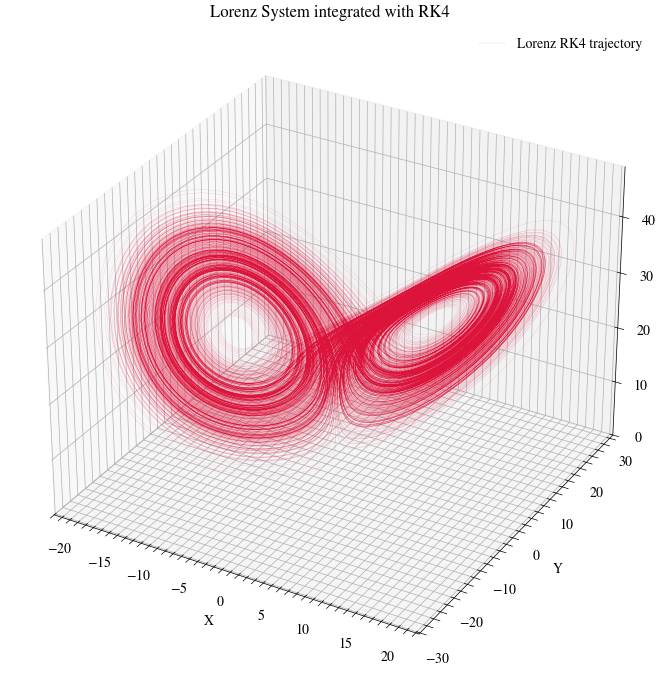

In [170]:
def lorenz_integrate(x0, T=1000.0, t_save_start=0.0, save_every=0.01, dt=0.01, sigma=10.0, rho=28.0, beta=8.0/3.0):
    num_steps = int(T / dt)
    start_step = int(t_save_start / dt)
    save_step_interval = int(save_every / dt)
    num_save_states = ((num_steps - start_step) // save_step_interval)

    history = np.zeros((num_save_states + 1, 3))
    save_idx = 0
    X_now = x0

    if start_step == 0:
        history[save_idx] = X_now.copy()
        save_idx += 1

    for step in range(1, num_steps + 1):
        X_now = rk4_step_lorenz(X_now, dt, sigma, rho, beta)

        if step >= start_step and (step - start_step) % save_step_interval == 0:
            history[save_idx] = X_now.copy()
            save_idx += 1

    return history

def lorenz_graph(history):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(projection='3d')
    ax.plot(history[:, 0], history[:, 1], history[:, 2], color='crimson', linewidth=0.05, label='Lorenz RK4 trajectory')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Lorenz System integrated with RK4')
    ax.legend()
    plt.tight_layout()
    plt.show()

history_test = lorenz_integrate(x0=np.array([1.0, 1.0, 1.0]), T=1000.0, dt=0.01)
lorenz_graph(history_test)

## in_lorenz

In [171]:
import numpy as np

# history_in_lorenz = lorenz_integrate(x0=np.array([1.0, 1.0, 1.0]), T=2000.0, dt=0.01)
# np.save(f"/content/drive/MyDrive/Lorenz_Simulations/in_lorenz.npy", history_in_lorenz[-1])

in_lorenz = np.load(f"/content/drive/MyDrive/Lorenz_Simulations/in_lorenz.npy")

# MLE LORENZ w TRAJECTORIES

In [166]:
import numpy as np

def lorenz_perturb_mle_step(x0, v, T=0.1, dt=0.01, eps0=1e-8, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x1 = x0 + v
    x0 = lorenz_integrate(x0=x0, T=T, dt=dt, sigma=sigma, rho=rho, beta=beta)[-1]
    x1 = lorenz_integrate(x0=x1, T=T, dt=dt, sigma=sigma, rho=rho, beta=beta)[-1]
    eps1 = np.linalg.norm(x1 - x0)
    mle = (1 / T) * np.log(eps1 / eps0)
    v = (eps0 / eps1) * (x1 - x0)
    return x0, v, mle

def lorenz_average_mle(x0, T=0.1, dt=0.01, eps0=1e-8, sigma=10.0, rho=28.0, beta=8.0/3.0, skip=500, M=100000):
    mle_sum = 0
    v = np.random.uniform(-1, 1, 3)
    v = (eps0 / np.linalg.norm(v)) * v
    for i in range(M):
        x0, v, mle = lorenz_perturb_mle_step(x0, v, T=T, dt=dt, eps0=eps0, sigma=sigma, rho=rho, beta=beta)
        if i >= skip:
            mle_sum += mle
    MLE = mle_sum / (M - skip)
    return MLE

lorenz_average_mle(x0=in_lorenz, T=0.1, dt=0.01, skip=500, M=100000)

np.float64(0.9057648928677481)

# MLE LORENZ w JACOBIAN

In [153]:
import numpy as np

def lorenz_jacobian(state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    J = np.array([
        [-sigma,   sigma,  0],
        [rho - z,  -1,    -x],
        [  y,       x,    -beta]])
    return J

# Integrate Lorenz (advance as usual) and tangent vector (Jacobian) with RK4
def lorenz_jacobian_integrate(x0, pert0, T=1.0, dt=0.01, sigma=10.0, rho=28.0, beta=8.0/3.0):
    num_steps = int(T / dt)
    state = x0.copy()
    v = pert0.copy()

    for _ in range(num_steps):
        k1_state = lorenz_der(state, sigma, rho, beta)
        k1_v = lorenz_jacobian(state, sigma, rho, beta) @ v

        state_k2 = state + 0.5 * dt * k1_state
        v_k2 = v + 0.5 * dt * k1_v
        k2_state = lorenz_der(state_k2, sigma, rho, beta)
        k2_v = lorenz_jacobian(state_k2, sigma, rho, beta) @ v_k2

        state_k3 = state + 0.5 * dt * k2_state
        v_k3 = v + 0.5 * dt * k2_v
        k3_state = lorenz_der(state_k3, sigma, rho, beta)
        k3_v = lorenz_jacobian(state_k3, sigma, rho, beta) @ v_k3

        state_k4 = state + dt * k3_state
        v_k4 = v + dt * k3_v
        k4_state = lorenz_der(state_k4, sigma, rho, beta)
        k4_v = lorenz_jacobian(state_k4, sigma, rho, beta) @ v_k4

        state = state + (dt / 6.0) * (k1_state + 2*k2_state + 2*k3_state + k4_state)
        v = v + (dt / 6.0) * (k1_v + 2*k2_v + 2*k3_v + k4_v)

    return state, v

def lorenz_jacobian_mle_step(x0, v, eps0, T=1.0, dt=0.01, sigma=10.0, rho=28.0, beta=8.0/3.0, skip=600, M=10000):
    x0, v = lorenz_jacobian_integrate(x0, v, T, dt, sigma, rho, beta)

    eps1 = np.linalg.norm(v)
    v = (eps0 / eps1) * v

    mle = (1 / T) * np.log(eps1 / eps0)

    return x0, v, mle

def lorenz_average_mle_jacobian(x0, T=1.0, dt=0.01, eps0=1e-8, sigma=10.0, rho=28.0, beta=8.0/3.0, skip=600, M=10000):
    # get the first v0 perturbation from x0 random
    v = np.random.uniform(-1, 1, 3)
    v = (eps0 / np.linalg.norm(v)) * v

    mle_sum = 0

    for i in range(M):
        x0, v, mle = lorenz_jacobian_mle_step(x0, v, eps0, T, dt, sigma, rho, beta)
        if i >= skip:
            mle_sum += mle

    MLE = 1 / (M - skip) * mle_sum
    return MLE

lorenz_average_mle_jacobian(x0=in_lorenz, T=1.0, dt=0.01, skip=600, M=10000)

np.float64(0.9056755974117375)

# BENETTIN ALGORITHM

In [172]:
import numpy as np

def benettin_lyapunov_spectrum(x0, T=1.0, dt=0.01, sigma=10.0, rho=28.0, beta=8.0/3.0, skip=600, M=10000):
    Q = np.eye(3)
    lyap_sums = np.zeros(3)

    for i in range(M):
        x0, Q = lorenz_jacobian_integrate(x0, Q, T, dt, sigma, rho, beta)
        Q, R = np.linalg.qr(Q) # Gram-Schmidt orthog w QR decomposition, R (upper-triangular) is the growth scales
        local_growth = np.abs(np.diag(R))
        local_growth = np.maximum(local_growth, 1e-15) # clamp the minimum value to 1e-15 to avoid log(0)

        if i >= skip:
            lyap_sums += np.log(local_growth)

    total_time = (M - skip) * T
    return lyap_sums / total_time

In [157]:
benettin_lyapunov_spectrum(x0=in_lorenz, T=1.0, dt=0.01, skip=600, M=10000)

array([ 9.05675597e-01,  1.27261226e-05, -1.45722529e+01])

# MSF

## Integration of Lorenz and MSF eq at the same time


In [10]:
# integrate lorenz and MSF diff eq at the same time, where we need the jacobian of g as input
def lorenz_msf_integrate(x0, v0, nu, i, j, T=1.0, dt=0.01, sigma=10.0, rho=28.0, beta=8.0/3.0):
    num_steps = int(T / dt)
    state = x0.copy()
    v = v0.copy()
    Jg = Jg_coupling_j_to_i(i,j)

    for _ in range(num_steps):
        # The MSF differential equation is dot(v) = [Jf(x) - nu * Jg] @ v
        k1_state = lorenz_der(state, sigma, rho, beta)
        J1 = lorenz_jacobian(state, sigma, rho, beta)
        k1_v = (J1 - nu * Jg) @ v

        state_k2 = state + 0.5 * dt * k1_state
        v_k2 = v + 0.5 * dt * k1_v

        k2_state = lorenz_der(state_k2, sigma, rho, beta)
        J2 = lorenz_jacobian(state_k2, sigma, rho, beta)
        k2_v = (J2 - nu * Jg) @ v_k2

        state_k3 = state + 0.5 * dt * k2_state
        v_k3 = v + 0.5 * dt * k2_v

        k3_state = lorenz_der(state_k3, sigma, rho, beta)
        J3 = lorenz_jacobian(state_k3, sigma, rho, beta)
        k3_v = (J3 - nu * Jg) @ v_k3

        state_k4 = state + dt * k3_state
        v_k4 = v + dt * k3_v

        k4_state = lorenz_der(state_k4, sigma, rho, beta)
        J4 = lorenz_jacobian(state_k4, sigma, rho, beta)
        k4_v = (J4 - nu * Jg) @ v_k4

        state += (dt / 6.0) * (k1_state + 2*k2_state + 2*k3_state + k4_state)
        v += (dt / 6.0) * (k1_v + 2*k2_v + 2*k3_v + k4_v)

    return state, v

def Jg_coupling_j_to_i(i,j):
    Jg = np.zeros((3,3))
    Jg[i-1,j-1] = 1
    return Jg

def lorenz_msf_at_nu_with_qr(x0, nu, i, j, T=1.0, dt=0.01, sigma=10.0, rho=28.0, beta=8.0/3.0, skip=600, M=10000):
    state = x0.copy()
    lyap_sums = np.zeros(3)
    Q = np.eye(3)

    for k in range(M):
        state, Q = lorenz_msf_integrate(state, Q, nu, i, j, T, dt, sigma, rho, beta)

        Q, R = np.linalg.qr(Q)
        local_growth = np.abs(np.diag(R))
        local_growth = np.maximum(local_growth, 1e-15) # clamp the minimum value to 1e-15 to avoid log(0)

        if k >= skip:
            lyap_sums += np.log(local_growth)

    total_time = (M - skip) * T
    exponents = lyap_sums / total_time

    return np.max(exponents) # MSF tracks the MLE

def lorenz_msf_nu_range_with_qr(x0, nu_range, i, j, T=1.0, dt=0.01, sigma=10.0, rho=28.0, beta=8.0/3.0, skip=600, M=10000):
    msf_values = []

    for nu in nu_range:
        msf_val = lorenz_msf_at_nu_with_qr(x0, nu, i, j, T, dt, sigma, rho, beta, skip, M)
        msf_values.append(msf_val)

        print(f'msf saved for nu = {nu}')

    return np.array(msf_values)


def lorenz_msf_at_nu(x0, nu, i, j, T=1.0, dt=0.01, eps0=1e-8, sigma=10.0, rho=28.0, beta=8.0/3.0, skip=600, M=10000):
    v = np.random.uniform(-1, 1, 3)
    v = (eps0 / np.linalg.norm(v)) * v

    mle_sum = 0
    state = x0.copy()

    for k in range(M):
        state, v = lorenz_msf_integrate(state, v, nu, i, j, T, dt, sigma, rho, beta)
        eps1 = np.linalg.norm(v)

        if k >= skip:
            mle_sum += (1 / T) * np.log(eps1 / eps0)

        v = (eps0 / eps1) * v

    MLE = mle_sum / (M - skip)

    return MLE

def lorenz_msf_nu_range(x0, nu_range, i, j, T=1.0, dt=0.01, eps0=1e-8, sigma=10.0, rho=28.0, beta=8.0/3.0, skip=600, M=10000):
    msf_values = []

    for nu in nu_range:
        msf_val = lorenz_msf_at_nu(x0, nu, i, j, T, dt, eps0, sigma, rho, beta, skip, M)
        msf_values.append(msf_val)

    return np.array(msf_values)

##Plot depending on coupling Jg

In [11]:
def lorenz_msf_plot(x0, nu_range, i, j, T=0.5, dt=0.01, eps0=1e-8, sigma=10.0, rho=28.0, beta=8.0/3.0, skip=30, M=300):
    msf_values = lorenz_msf_nu_range(x0, nu_range, i, j, T, dt, eps0, sigma, rho, beta, skip, M)

    plt.plot(nu_range, msf_values)
    plt.axhline(0, color='black')
    plt.axvline(0, color='black')
    plt.grid(True, alpha=0.7)

    plt.xlabel('$\\nu$')
    plt.ylabel('MLE')
    plt.title(f'Master Stability Function for Lorenz System ({j}->{i})')

    sync_zone = nu_range[msf_values < 0]
    if len(sync_zone) > 0:
        plt.fill_between(nu_range, msf_values, 0, where=(msf_values < 0), color='gray', alpha=0.2)
    plt.tight_layout()

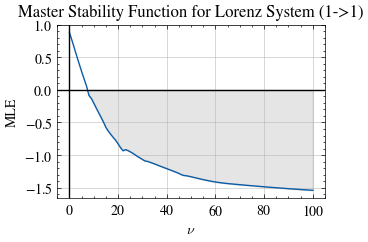

In [158]:
lorenz_msf_plot(x0=in_lorenz, nu_range=np.linspace(0, 100, 101), i=1, j=1, T=0.5)

## Get MSF class and zeros of $(\nu, \text{MSF}(\nu))$.

In [13]:
# VERY SLOW
def get_msf_class_zeros_slow(x0, nu_range, i, j, T, dt=0.01, eps0=1e-8, sigma=10.0, rho=28.0, beta=8.0/3.0, skip=30, M=300):
    msf_values = lorenz_msf_nu_range(in_lorenz, nu_range, i, j, T, dt, eps0, sigma, rho, beta, skip, M)

    # nu_neg_msf_vals = nu_range[msf_values < 0] # gives the indices where msf_values is negative
    indices_msf_zeros = np.where(np.diff(np.sign(msf_values)))[0] # gives the indices where msf_values changes sign
    zeros = nu_range[indices_msf_zeros]
    l = len(zeros)

    if l == 0:
        class_msf = 1
    elif l == 1:
        class_msf = 2
    else:
        class_msf = 3
    return class_msf, zeros

In [15]:
# FASTER BUT NEED VALUES AT BOTH SIDES OF THE ZERO TO FIND IT (LOOK AT THE GRAPH IN 9GRAPHS TO GET THESE VALUES)
def get_msf_zero(x0, nu0, nu1, i, j, T, dt=0.01, eps0=1e-8, sigma=10.0, rho=28.0, beta=8.0/3.0, skip=30, M=300, tol=1e-4, max_iter=20):
    msf_nu0 = lorenz_msf_at_nu(x0, nu0, i, j, T, dt, eps0, sigma, rho, beta, skip, M)
    print('First MSF value obtained')

    msf_nu1 = lorenz_msf_at_nu(x0, nu1, i, j, T, dt, eps0, sigma, rho, beta, skip, M)
    print('Second MSF value obtained')

    if msf_nu0 * msf_nu1 > 0:
        return None, np.inf
    for k in range(max_iter):
        nu_med = (nu0 + nu1) / 2.0
        msf_med = lorenz_msf_at_nu(x0, nu_med, i, j, T, dt, eps0, sigma, rho, beta, skip, M)

        if abs(msf_med) < 1e-15 or (nu1 - nu0) / 2.0 < tol:
            print(f"Bisección: Convergió en {k+1} iteraciones.")
            return nu_med, tol

        if msf_nu0 * msf_med < 0:
            nu1 = nu_med
            msf_nu1 = msf_med
        else:
            nu0 = nu_med
            msf_nu0 = msf_med

        print(f'Iteration {k+1} completed, nu_med={nu_med}')

    return (nu0 + nu1) / 2.0, (nu1 - nu0) / 2.0

In [16]:
x0 = in_lorenz
dt = 0.01
T = 1.0
eps0 = 1e-8
skip = 600
M = 10000

def msf_class_and_zeros(i, j):
    if i == 1 and j == 1:
        msf_class = 2
        zeros = [7.8115]
    elif i == 1 and j == 2:
        msf_class = 3
        zeros = [3.9626, 23.6467]
    elif i == 2 and j == 1:
        msf_class = 2
        zeros = [7.1241]
    elif i == 2 and j == 2:
        msf_class = 2
        zeros = [2.7579]
    elif i == 3 and j == 3:
        msf_class = 3
        zeros = [1.4146, 6.0921]
    elif (i == 1 and j == 3) or (i == 2 and j == 3) or (i == 3 and j == 1) or (i == 3 and j == 2):
        msf_class = 1
        zeros = []
    return msf_class, zeros

## 9 GRAPHS (i -> j) MSF

SLOW WAY (in-code)

In [159]:
# dt = 0.01
# T = 0.2
# skip = 30
# M = 300
# nu_range = np.linspace(0, 100, 101)

# plt.figure(figsize=(15,10))
# x0 = in_lorenz
# for i in range(1, 4):
#     for j in range(1, 4):
#         plt.subplot(3, 3, (j-1) * 3 + i)
#         lorenz_msf_plot(x0, nu_range, i, j, T, dt)
#         plt.title(f'{j} -> {i}')

# plt.suptitle('Master Stability Function for Lorenz System', fontweight='bold', fontsize=16)
# plt.subplots_adjust(top=0.9, bottom=0, left=0, right=1, hspace=0.3, wspace=0.3)
# plt.show()

FAST (saved files)

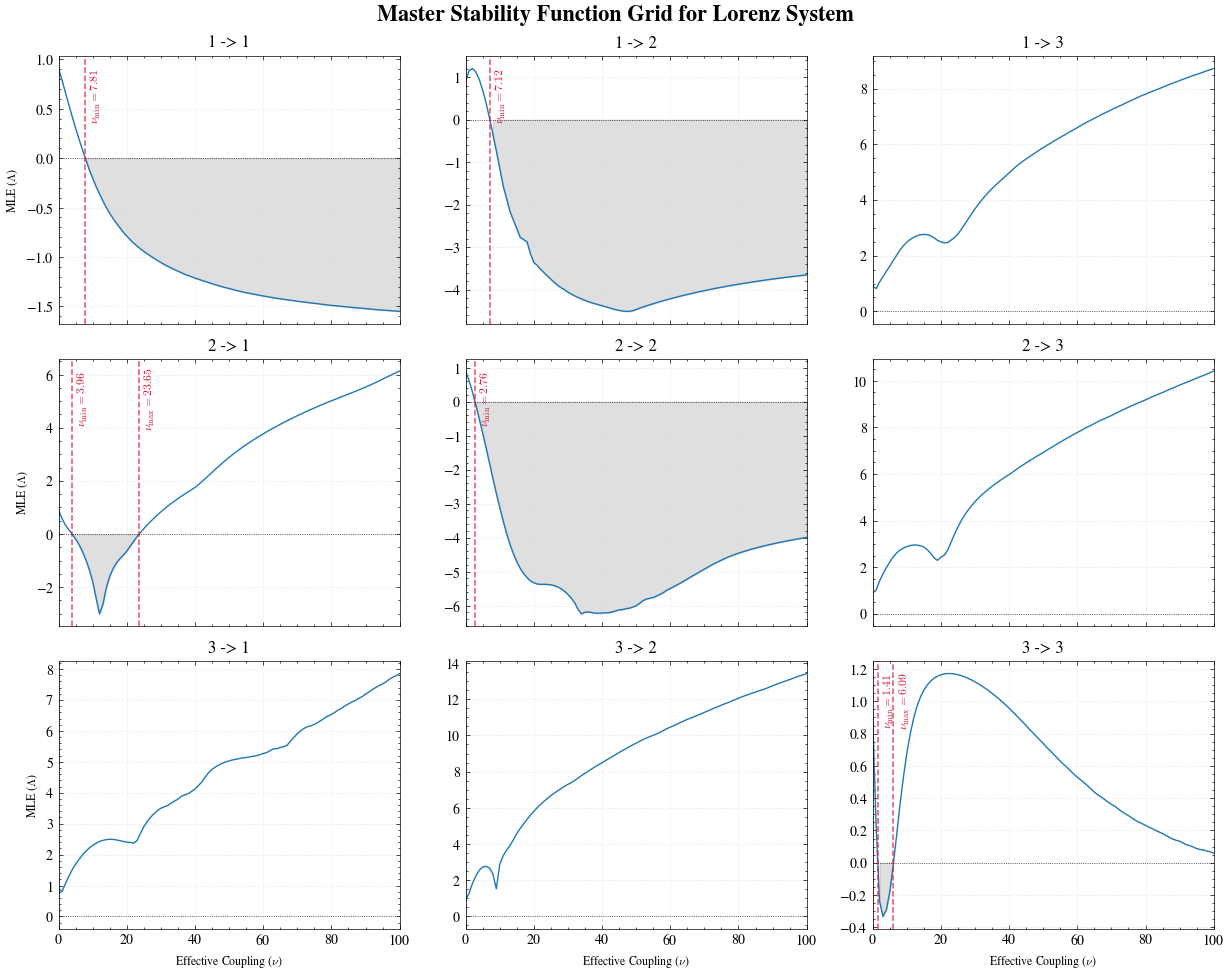

In [163]:
import os
import numpy as np
import matplotlib.pyplot as plt
def generate_msf_incremental(x0, nu_range, i, j, T=1.0, dt=0.01, eps0=1e-8, skip=1000, M=10000):
    base_path = f"/content/drive/MyDrive/Lorenz_Simulations/MSF_Grid/Coupling_j{j}_to_i{i}"
    os.makedirs(base_path, exist_ok=True)

    for nu in nu_range:
        filename = f"{base_path}/msf_i{i}_j{j}_nu_{nu:.2f}.npy"

        if os.path.exists(filename):
            continue

        print(f"Calculating nu = {nu:.2f} ...", end=" ")

        msf_val = lorenz_msf_at_nu(x0, nu, i, j, T=T, dt=dt, eps0=eps0, skip=skip, M=M)

        np.save(filename, msf_val)
        print("Saved!")

def plot_msf_grid_live(nu_range):
    fig, axes = plt.subplots(3, 3, figsize=(12.5, 10), sharex=True)

    for i in range(1, 4):
        for j in range(1, 4):
            base_path = f"/content/drive/MyDrive/Lorenz_Simulations/MSF_Grid/Coupling_j{j}_to_i{i}"
            # ax = plt.subplot(3, 3, (j-1) * 3 + i)
            ax = axes[j - 1, i - 1]

            msf_values = []
            loaded_nus = []

            for nu in nu_range:
                filename = f"{base_path}/msf_i{i}_j{j}_nu_{nu:.2f}.npy"

                if os.path.exists(filename):
                    msf_values.append(np.load(filename))
                    loaded_nus.append(nu)

            msf_values = np.array(msf_values)
            loaded_nus = np.array(loaded_nus)

            if len(msf_values) == 0:
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            ax.plot(loaded_nus, msf_values, color='#1f77b4', linewidth=1.0)
            ax.axhline(0, color='black', linestyle=':', linewidth=0.6, alpha=0.8)
            ax.axvline(0, color='black', linestyle=':', linewidth=0.6, alpha=0.8)

            if np.any(msf_values < 0):
                ax.fill_between(loaded_nus, msf_values, 0, where=(msf_values < 0), color='gray', alpha=0.25)

            _, zeros = msf_class_and_zeros(i, j)
            for idx, z in enumerate(zeros):
                ax.axvline(x=z, color="crimson", linestyle="--", linewidth=1.1, alpha=0.75)
                label_text = (rf"$\nu_{{\min}} = {z:.2f}$" if idx == 0 else rf"$\nu_{{\max}} = {z:.2f}$")
                ax.text(z + 1.2, 0.85, label_text, transform=ax.get_xaxis_transform(), color="crimson", fontsize=8.5, rotation=90, va="center", ha="left")

            ax.set_title(f"{j} -> {i}")
            ax.grid(True, color='lightgray', linestyle='--', linewidth=0.4, alpha=0.5)
            ax.set_xlim([0, 100])

            if j == 3: ax.set_xlabel(r'Effective Coupling ($\nu$)', fontsize=8.5)
            if i == 1: ax.set_ylabel(r'MLE ($\Lambda$)', fontsize=8.5)
    plt.suptitle('Master Stability Function Grid for Lorenz System', fontweight='bold', fontsize=16)
    plt.tight_layout()
    plt.show()

# x0 = in_lorenz
# generate_msf_incremental(x0, nu_range, i=1, j=1, T=1.0, dt=0.01, eps0=1e-8, skip=600, M=10000)

nu_range = np.linspace(0, 100, 101)
plot_msf_grid_live(nu_range)

# LORENZ IN COUPLED NETWORK

## Integration

In [173]:
def lorenz_der_nodes(state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x = state[:, 0]
    y = state[:, 1]
    z = state[:, 2]

    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z

    return np.column_stack((dxdt, dydt, dzdt))

def g_coupling_j_to_i(X, i, j):
    g = np.zeros_like(X)
    g[:, i-1] = X[:, j-1]
    return g

def rk4_step_network(X, L, i, j, alpha, dt=0.01, sigma=10.0, rho=28.0, beta=8.0/3.0):
    # Gives RK4 step of dX/dt = f(X) - alpha * (L @ g(X)), with dim X = (N,3)

    k1 = lorenz_der_nodes(X, sigma, rho, beta) - alpha * (L @ g_coupling_j_to_i(X,i,j))

    X2 = X + 0.5 * dt * k1
    k2 = lorenz_der_nodes(X2, sigma, rho, beta) - alpha * (L @ g_coupling_j_to_i(X2,i,j))

    X3 = X + 0.5 * dt * k2
    k3 = lorenz_der_nodes(X3, sigma, rho, beta) - alpha * (L @ g_coupling_j_to_i(X3,i,j))

    X4 = X + dt * k3
    k4 = lorenz_der_nodes(X4, sigma, rho, beta) - alpha * (L @ g_coupling_j_to_i(X4,i,j))

    return X + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def lorenz_integrate_network(x0, L, i, j, alpha, T=200.0, t_save_start=0.0, save_every=0.01, dt=0.01, eps=1e-8, sigma=10.0, rho=28.0, beta=8.0/3.0):
    N = len(L)
    num_steps = int(T / dt)
    start_step = int(t_save_start / dt)
    if save_every < dt:
        save_every = dt
    save_step_interval = int(save_every / dt)

    num_save_states = ((num_steps - start_step) // save_step_interval)
    history = np.zeros((num_save_states + 1, N, 3))
    save_idx = 0

    X0 = np.zeros((N, 3))
    for k in range(N):
        if eps > 0: # not in sync state, we need to add perturb
            v = np.random.uniform(-1, 1, 3)
            X0[k] = x0 + (eps / np.linalg.norm(v)) * v
        else:
            X0[k] = x0.copy()
    X_now = X0

    if start_step == 0:
        history[save_idx] = X_now.copy()
        save_idx += 1

    for step in range(1, num_steps + 1):
        X_now = rk4_step_network(X_now, L, i, j, alpha, dt, sigma, rho, beta)

        if step >= start_step and (step - start_step) % save_step_interval == 0:
            history[save_idx] = X_now.copy()
            save_idx += 1

    return history

## Synchronization error !!!

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def sync_error(network_history):
    network_mean = np.mean(network_history, axis=1, keepdims=True)
    sq_norm = np.sum((network_history - network_mean)**2, axis=2) # axis 2 is variables
    instantaneous_error = np.sqrt(np.mean(sq_norm, axis=1)) # axis 1 is nodes
    E = np.mean(instantaneous_error)
    return E

def mean_sync_error(x0, nu_range, L, i, j, num_err=5, T=2000.0, t_save_start=500.0, save_every=100.0, dt=0.01, eps=1e-8):
    N = len(L)
    average_errors = []

    eigenvals = get_sorted_eigenvals(L)
    lambda2 = np.real(eigenvals[1])

    for nu in nu_range:
        alpha = nu / lambda2
        errors = []
        for m in range(num_err):
            network_history = lorenz_integrate_network(x0, L, i, j, alpha, T, t_save_start, save_every, dt, eps)
            E_m = sync_error(network_history)
            errors.append(E_m)

        E_tilde = np.mean(errors)
        average_errors.append(E_tilde)

    return average_errors

def plot_mean_sync_error(nu_range, average_errors, num_err, N, i, j):
    plt.figure(figsize=(10, 6))
    plt.plot(nu_range, average_errors)
    plt.axhline(0, color='gray', linewidth=1.2)
    plt.axvline(0, color='gray', linewidth=1.2)

    plt.title(f'Average Synchronization Error (num_err={num_err}, N={N}, Coupling {j}->{i})', fontweight='bold')
    plt.xlabel(r'$\nu$')
    plt.ylabel(r'$\tilde{E}$')
    plt.grid(True, alpha=0.3)
    plt.show()

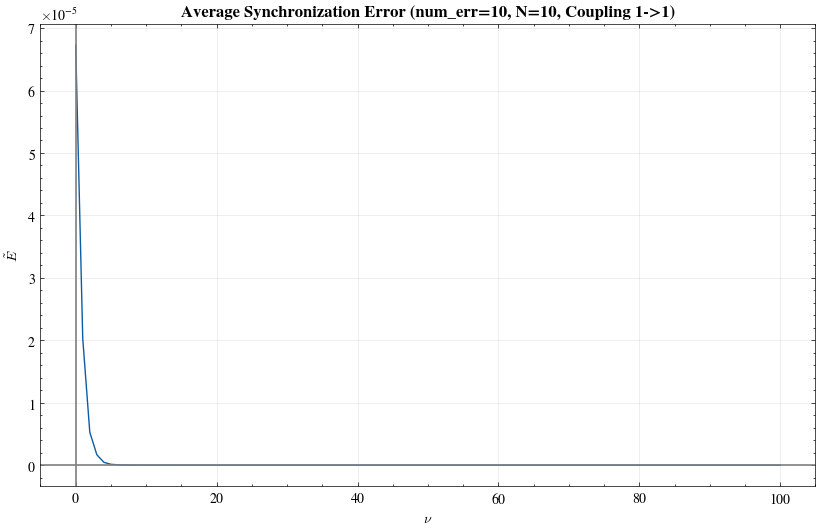

In [165]:
nu_range = np.linspace(0, 100, 101)
N = 10
G_comp = create_graph('complete', N)
L = nx.laplacian_matrix(G_comp).toarray().astype(float)

i = 1
j = 1
num_err=10

average_errors = mean_sync_error(x0, nu_range, L, i, j, num_err, T=10.0, t_save_start=0.0, save_every=0.1, eps=1e-8)
plot_mean_sync_error(nu_range, average_errors, num_err, N, i, j)

# MSF - NETWORK: CRITICAL ALPHAS (LORENZ)


## Get critical alphas

In [23]:
def get_msf_class_critical_alphas_network_slow(x0, nu_range, i, j, L, T=0.5, dt=0.01, eps0=1e-8, sigma=10.0, rho=28.0, beta=8.0/3.0, skip=30, M=300):
    msf_class, critical_nus = get_msf_class_zeros_slow(x0, nu_range, i, j, T, dt, eps0, sigma, rho, beta, skip, M)

    l = len(critical_nus)
    if l == 0:
        values_alphas = [1]
    else:
        eigenvals = get_sorted_eigenvals(L)
        lambda2 = np.real(eigenvals[1])
        critical_alphas = critical_nus/lambda2

        values_alphas = np.zeros(l+1)
        values_alphas[0] = round((0 + critical_alphas[0])/2, 4)
        for k in range(l-1):
            values_alphas[k+1] = round((critical_alphas[k] + critical_alphas[k+1])/2, 4)
        values_alphas[-1] = round((critical_alphas[-1] + 100)/2, 4)

    return msf_class, critical_alphas, values_alphas

def msf_class_critical_alphas_network(i, j, L):
    msf_class, critical_nus = msf_class_and_zeros(i, j)

    l = len(critical_nus)
    if l == 0:
        critical_alphas = critical_nus
        values_alphas = [1.0000]
    else:
        eigenvals = get_sorted_eigenvals(L)
        lambda2 = np.real(eigenvals[1])
        critical_alphas = critical_nus/lambda2

        values_alphas = np.zeros(l+1)
        values_alphas[0] = round((0 + critical_alphas[0])/2, 4)
        for k in range(l-1):
            values_alphas[k+1] = round((critical_alphas[k] + critical_alphas[k+1])/2, 4)
        values_alphas[-1] = round((critical_alphas[-1] + 100)/2, 4)

    return msf_class, critical_alphas, values_alphas


# plot all nodes' variable x in a side by side comparison of the critical alphas that confirm it is in the synch/non-synch region suspected (first region is always non-sync and then they alternate)
def plot_msf_alphas_network_xdim(x0, L, i, j, values_alphas = [1], T = 500, dt = 0.01):
    plt.figure(figsize=(12,3))

    N = len(L)
    num_steps = int(T / dt)
    t = np.linspace(0, T, num_steps)

    l = len(values_alphas)

    for p in range(l): # p is the number of subplot we are doing. p-1 will be the variable we are plotting
        alpha = values_alphas[p]

        # history is (Times, Nodes, Variables). history[:, 0, 0] means All time steps, Node 0, Variable x
        history = lorenz_integrate_network(x0, L, i, j, alpha, T, dt)

        plt.subplot(1, l, p+1)
        for k in range(N):
            plt.plot(t, history[:, k, 0], label=f'Node {k}', alpha=0.7)
        plt.title(f'$\\alpha$ = {alpha}')
        plt.xlabel('t')
        # plt.ylabel("$\\dot{x_i}$")
        plt.legend(loc='lower right')

    plt.suptitle(f'Lorenz Network comparison of alphas on variable x ({N} nodes and coupling {j}->{i})', fontweight='bold')
    plt.subplots_adjust(top=0.8, bottom=0, left=0, right=1, hspace=0.3, wspace=0.3)
    plt.show()


# plot all lorenz trajectories in 3D of all nodes in the same figure
def plot_msf_alphas_network_trajectories(x0, L, i, j, values_alphas = [1], T = 100, dt = 0.01):
    fig = plt.figure(figsize=(12,3))
    num_steps = int(T / dt)
    t = np.linspace(0, T, num_steps)

    l = len(values_alphas)
    for p in range(l): # l is the number of subplots we are doing. p will be the index of values_alphas we are plotting
        alpha = values_alphas[p]
        history = lorenz_integrate_network(x0, L, i, j, alpha, T, dt)

        ax = fig.add_subplot(1, l, p+1, projection='3d')

        for node in range(len(history[0,:,0])):
            ax.plot(history[:,node,0], history[:,node,1], history[:,node,2], alpha = 0.8, linewidth=0.3, label=f'Node {node}')

        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.set_title(f'$\\alpha$ = {alpha}')
        ax.legend(loc='lower right')
    plt.subplots_adjust(top=0.8, bottom=0, left=0, right=1, hspace=0, wspace=0.01)
    plt.suptitle(f'Lorenz System Network comparison of alphas integrated with RK4 ({N} nodes and coupling {j}->{i})', fontweight='bold')
    plt.show()

## Plot for specific $\alpha$ and see if it is in sychr or non-sync region

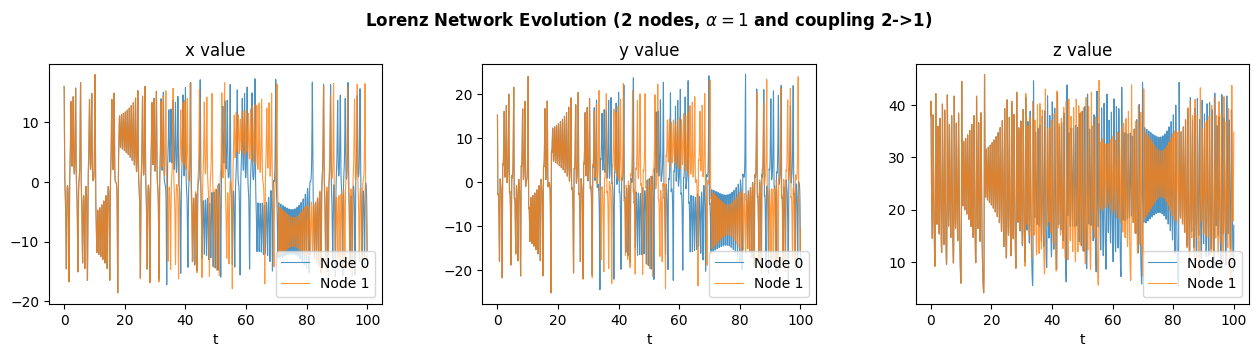

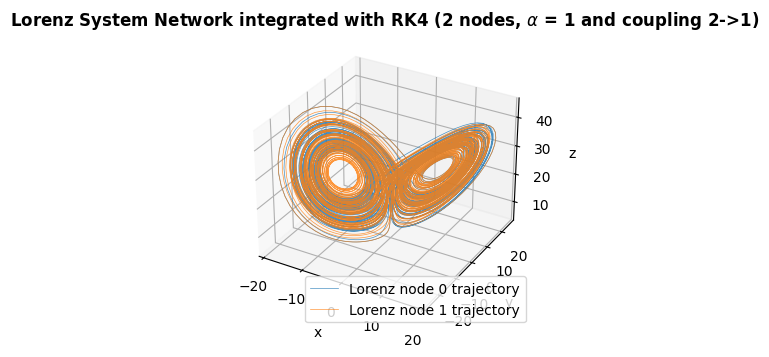

In [24]:
# do an experiment choosing i and j to determine g, and alpha in a syncronization or non-synchr region
i = 1
j = 2
alpha = 1
x0 = in_lorenz
N = 2

T = 100
dt = 0.01
num_steps = int(T / dt)

G_comp = create_graph('complete', N=N)
L = nx.laplacian_matrix(G_comp).toarray().astype(float)

history = lorenz_integrate_network(x0=x0, L=L, i=i, j=1, alpha=alpha, T=T, dt=dt)
# plot all nodes variable by variable side by side to see if there's synchronization or not
plt.figure(figsize=(12,3))
t = np.linspace(0, T, num_steps + 1)
# history is (Times, Nodes, Variables). history[:, 0, 0] means All time steps, Node 0, Variable x

titles = ['x value', 'y value', 'z value']
for p in range(1,4): # p is the number of subplot we are doing. p-1 will be the variable we are plotting
    plt.subplot(1, 3, p)
    for k in range(N):
        plt.plot(t, history[:, k, p-1], label=f'Node {k}', alpha=0.8, linewidth=0.8)
    plt.title(titles[p-1])
    plt.xlabel('t')
    # plt.ylabel("$\\dot{x_i}$")
    plt.legend(loc='lower right')

plt.suptitle(f'Lorenz Network Evolution ({N} nodes, $\\alpha = {alpha}$ and coupling {j}->{i})', fontweight='bold')
plt.subplots_adjust(top=0.8, bottom=0, left=0, right=1, hspace=0.3, wspace=0.3)
plt.show()


# plot all lorenz trajectories in 3D of all nodes in the same figure
fig = plt.figure(figsize=(5, 3.5))
ax = fig.add_subplot(projection='3d')
for node in range(len(history[0,:,0])):
    ax.plot(history[:,node,0], history[:,node,1], history[:,node,2], alpha = 0.8, linewidth=0.5, label=f'Lorenz node {node} trajectory')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(f'Lorenz System Network integrated with RK4 ({N} nodes, $\\alpha$ = {alpha} and coupling {j}->{i})', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Example class I: 3 -> 1

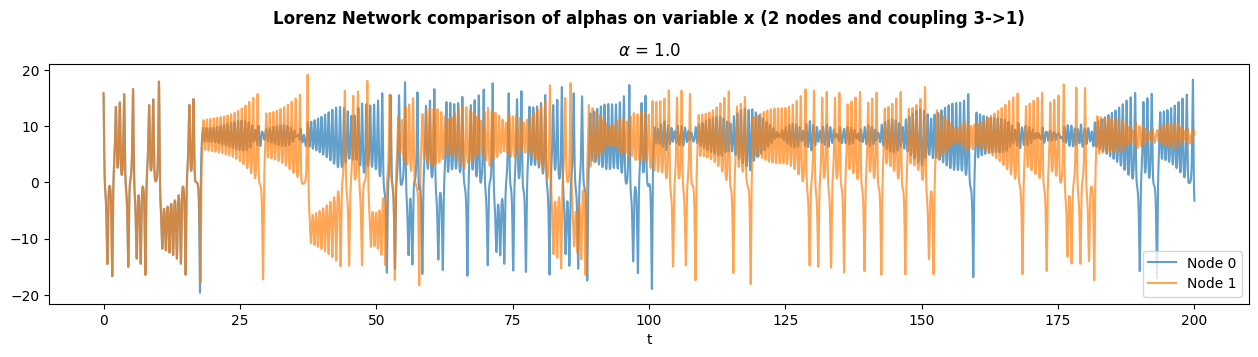

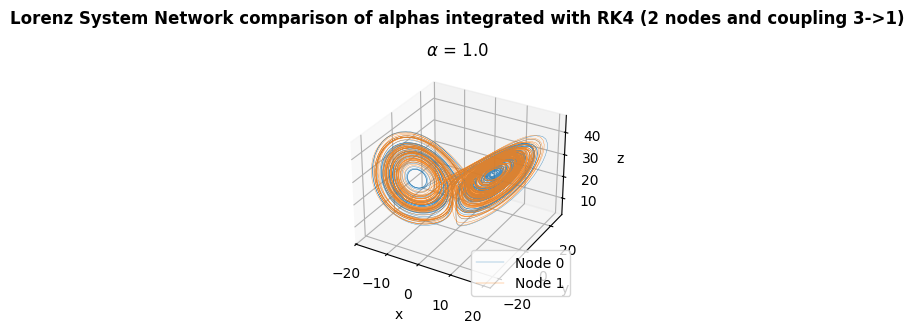

MSF class: 1
critical alphas: []
values alpha: [1.0]


In [25]:
x0 = in_lorenz
nu_range = np.linspace(0, 100, 101)
N = 2
G_comp = create_graph('complete', N)
L = nx.laplacian_matrix(G_comp).toarray().astype(float)
T = 200
i = 1
j = 3

msf_class, critical_alphas, values_alphas = msf_class_critical_alphas_network(i, j, L)
plot_msf_alphas_network_xdim(x0, L, i, j, values_alphas, T=T)
plot_msf_alphas_network_trajectories(x0, L, i, j, values_alphas, T=T/2)

print(f'MSF class: {msf_class}')
print(f'critical alphas: {critical_alphas}')
print(f'values alpha: {values_alphas}')

## Example class II: 1 -> 1

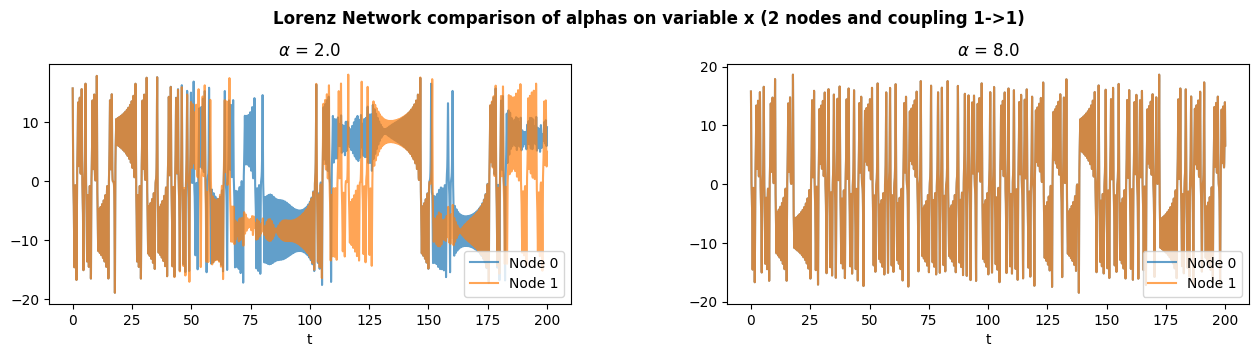

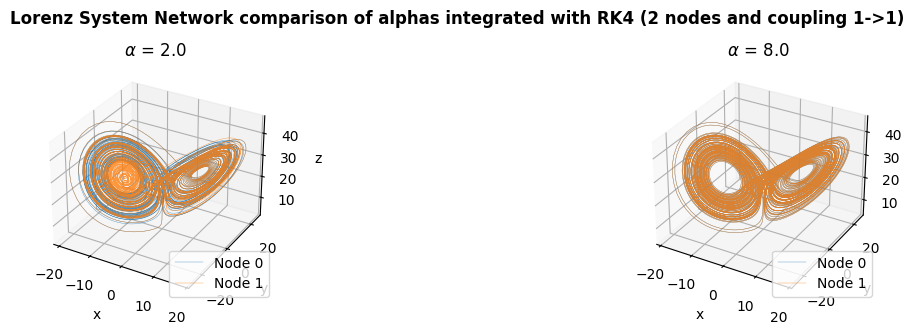

In [26]:
x0 = in_lorenz
nu_range = np.linspace(0, 100, 101)
N = 2
G_comp = create_graph('complete', N)
L = nx.laplacian_matrix(G_comp).toarray().astype(float)
T = 200
i = 1
j = 1

values_alphas=[2.0, 8.0]
plot_msf_alphas_network_xdim(x0, L, i, j, values_alphas, T=T)
plot_msf_alphas_network_trajectories(x0, L, i, j, values_alphas, T=T/2)

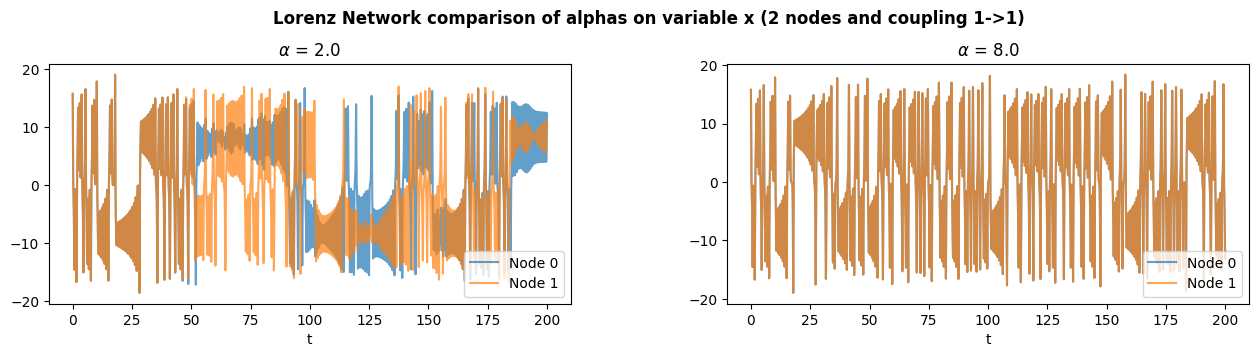

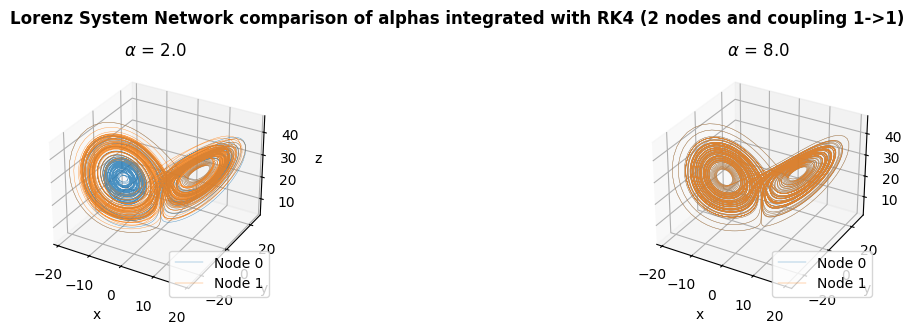

MSF class: 2
critical alphas: [3.90575]
values alpha: [2.0, 8.0]


In [27]:
x0 = in_lorenz
nu_range = np.linspace(0, 100, 101)
N = 2
G_comp = create_graph('complete', N)
L = nx.laplacian_matrix(G_comp).toarray().astype(float)
T = 200
i = 1
j = 1

msf_class, critical_alphas, values_alphas = msf_class_critical_alphas_network(i, j, L)
values_alphas=[2.0, 8.0]
plot_msf_alphas_network_xdim(x0, L, i, j, values_alphas, T=T)
plot_msf_alphas_network_trajectories(x0, L, i, j, values_alphas, T=T/2)

print(f'MSF class: {msf_class}')
print(f'critical alphas: {critical_alphas}')
print(f'values alpha: {values_alphas}')

## Example class III: 2 -> 1

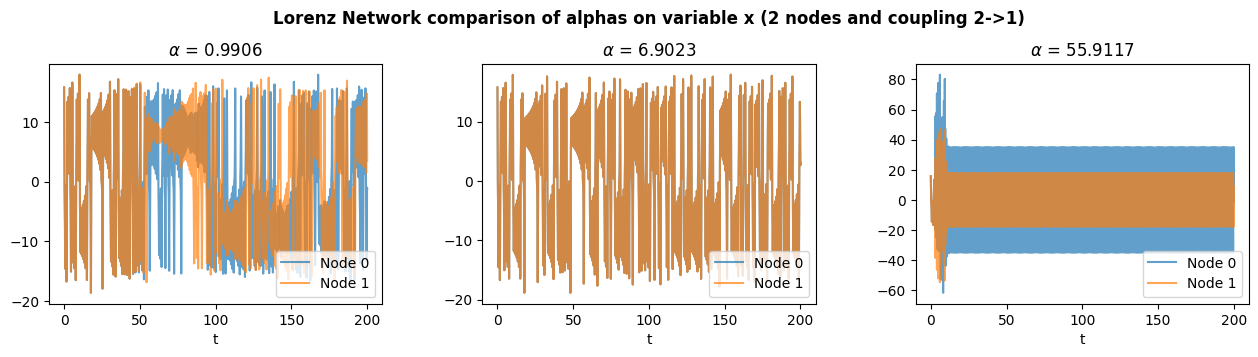

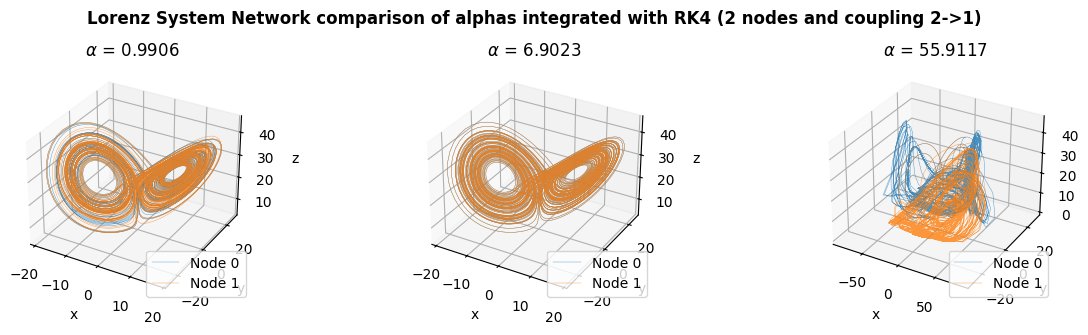

MSF class: 3
critical alphas: [ 1.9813  11.82335]
values alpha: [ 0.9906  6.9023 55.9117]


In [28]:
x0 = in_lorenz
nu_range = np.linspace(0, 100, 101)
N = 2
G_comp = create_graph('complete', N)
L = nx.laplacian_matrix(G_comp).toarray().astype(float)
T = 200
i = 1
j = 2

msf_class, critical_alphas, values_alphas = msf_class_critical_alphas_network(i, j, L)
plot_msf_alphas_network_xdim(x0, L, i, j, values_alphas, T=T)
plot_msf_alphas_network_trajectories(x0, L, i, j, values_alphas, T=T/2)

print(f'MSF class: {msf_class}')
print(f'critical alphas: {critical_alphas}')
print(f'values alpha: {values_alphas}')

# ANALYZE NETWORK SYNCHRONIZABILITY

In [29]:
import numpy as np

def analyze_network_synchronizability(L, i, j):
    msf_class, nu_zeros = msf_class_and_zeros(i, j)

    eigenvals = np.sort(np.real(np.linalg.eigvals(L)))
    lambda2 = float(eigenvals[1])
    lambda_n = float(eigenvals[-1])
    eigenratio = lambda_n / lambda2

    # Class I: Lambda(nu) > 0 for all nu > 0
    if msf_class == 1:
        return {"class": "I", "synchronizable": False,
                "lambda2": lambda2, "lambda_n": lambda_n, "eigenratio": eigenratio}

    # Class II: sync region (nu_min, infinity)
    elif msf_class == 2:
        nu_min = float(nu_zeros[0])
        alpha_min = nu_min / lambda2
        return {"class": "II", "synchronizable": True, "nu_min": nu_min, "alpha_min": alpha_min,
                "lambda2": lambda2, "lambda_n": lambda_n, "eigenratio": eigenratio}

    # Class III: sync region (nu_min, nu_max)
    else:
        nu_min = float(nu_zeros[0])
        nu_max = float(nu_zeros[1])
        msf_ratio = nu_max / nu_min

        if eigenratio > msf_ratio:
            return {"class": "III", "synchronizable": False, "nu_min": nu_min, "nu_max": nu_max, "msf_ratio": msf_ratio,
                    "lambda2": lambda2, "lambda_n": lambda_n, "eigenratio": eigenratio}
        else:
            alpha_min = nu_min / lambda2
            alpha_max = nu_max / lambda_n
            return {"class": "III", "synchronizable": True, "nu_min": nu_min, "nu_max": nu_max, "msf_ratio": msf_ratio,
                    "alpha_min": alpha_min, "alpha_max": alpha_max,
                    "lambda2": lambda2, "lambda_n": lambda_n, "eigenratio": eigenratio}

In [30]:
G_ba = create_graph("BA", N=10, m=2)
L_ba = np.asarray(nx.laplacian_matrix(G_ba).todense())

ba_N20_m2 = analyze_network_synchronizability(L_ba, i=1, j=2)
ba_N20_m2

{'class': 'III',
 'synchronizable': False,
 'nu_min': 3.9626,
 'nu_max': 23.6467,
 'msf_ratio': 5.9674708524705995,
 'lambda2': 0.9522399459084574,
 'lambda_n': 9.045145409673058,
 'eigenratio': 9.498809043390628}

# ERROR FOR ALL GRAPHS

## save and load functions

In [31]:
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

def run_single_realization(seed, folder_name, x0, nu_range, L, i, j, important_nus, T=500.0, t_save_start=50.0, save_every=0.5, dt=0.01, eps=1e-8):
    np.random.seed(seed)
    eigenvals = get_sorted_eigenvals(L)
    lambda2 = np.real(eigenvals[1])

    errors_for_this_seed = []

    important_nus_rounded = [round(n, 3) for n in important_nus]

    for nu in nu_range:
        alpha = np.real(nu / lambda2)
        history = lorenz_integrate_network(x0, L, i, j, alpha, T, t_save_start, save_every, dt, eps)
        error = sync_error(history)
        errors_for_this_seed.append(error)

        if round(nu, 3) in important_nus_rounded:
            existing_files = glob.glob(f"{folder_name}/trajectory_nu_{round(nu, 3)}_seed_*.npy")

            if len(existing_files) == 0:
                save_filename = f"{folder_name}/trajectory_nu_{round(nu, 3)}_seed_{seed}.npy"
                np.save(f"{folder_name}/trajectory_nu_{round(nu, 3)}_seed_{seed}.npy", history)
                print(f"Saved representative trajectory for nu = {nu:.2f} (Seed: {seed})")

    np.save(f"{folder_name}/errors_seed_{seed}.npy", errors_for_this_seed)

def generate_data(x0, L, network_model, i, j, M, important_nus, T=500.0, t_save_start=50.0, save_every=0.5, dt=0.01, eps=1e-8):
    N = L.shape[0]
    base_path = "/content/drive/MyDrive/Lorenz_Simulations"

    folder_name = (f"{base_path}/simulation_data_{network_model}_N{N}_i{i}_j{j}")
    os.makedirs(folder_name, exist_ok=True)

    nu_range = np.linspace(0, 100, 101)

    for m in range(M):
        seed = np.random.randint(0, 99999999)
        print(f"Realization {m+1}/{M} | Network: {network_model} | Seed: {seed} running...")
        run_single_realization(seed, folder_name, x0, nu_range, L, i, j, important_nus, T, t_save_start, save_every, dt, eps)

def load_and_plot_robust_results(L, network_model, N, i, j, save_image=True):
    base_path = "/content/drive/MyDrive/Lorenz_Simulations"
    folder_name = f"{base_path}/simulation_data_{network_model}_N{N}_i{i}_j{j}"
    file_list = glob.glob(f"{folder_name}/errors_seed_*.npy")

    completed_runs = len(file_list)
    if completed_runs == 0:
        return None

    all_realization_errors = [np.load(file) for file in file_list]
    mean_errors = np.mean(all_realization_errors, axis=0)

    nu_range = np.linspace(0, 100, 101)

    plt.figure(figsize=(10, 6))
    plt.plot(nu_range, mean_errors, color='crimson', linewidth=1.5)
    # plt.yscale('log')

    _, msf_zeros = msf_class_and_zeros(i, j)
    if len(msf_zeros) == 1:
        y_max = np.nanmax(mean_errors) if len(mean_errors) > 0 else 10.0
        text_y_pos = y_max * 0.95  # Position text at 75% height of the plot
        nu_net_min = msf_zeros[0]
        plt.axvline(x=nu_net_min, color='green', linestyle='--', alpha=0.6, label=rf"$\nu_{{\min}} = {nu_net_min:.2f}$")
        plt.text(nu_net_min + 0.3, text_y_pos, rf"$\nu_{{\min}} = {nu_net_min:.2f}$", rotation=90, color="green", fontsize=9, verticalalignment="center")
        plt.axvspan(nu_net_min, 100, color="grey", alpha=0.05, label="Stability Region")
    elif len(msf_zeros) > 1:
        y_max = np.nanmax(mean_errors) if len(mean_errors) > 0 else 10.0
        text_y_pos = y_max * 0.95  # Position text at 75% height of the plot
        nu_net_min = msf_zeros[0]
        eigenvals = get_sorted_eigenvals(L)
        r = eigenvals[-1] / eigenvals[1]
        nu_net_max = msf_zeros[1] / r  # ~ 5.46
        plt.axvline(x=nu_net_min, color='green', linestyle='--', alpha=0.6, label=rf"$\nu_{{\min}} = {nu_net_min:.2f}$")
        plt.text(nu_net_min + 0.3, text_y_pos, rf"$\nu_{{\min}} = {nu_net_min:.2f}$", rotation=90, color="green", fontsize=9, verticalalignment="center")
        plt.axvline(x=nu_net_max, color='navy', linestyle='--', alpha=0.6, label=rf"$\nu_{{\max}}/r = {nu_net_max:.2f}$")
        plt.text(nu_net_max + 0.3, text_y_pos, rf"$\nu_{{\max}}/r = {nu_net_max:.2f}$", rotation=90, color="navy", fontsize=9, verticalalignment="center")
        if nu_net_max > nu_net_min:
            plt.axvspan(nu_net_min, nu_net_max, color="grey", alpha=0.05, label="Stability Region")

    plt.xlim(left=0)  # Or (0,100) later
    plt.ylim(bottom=0)
    plt.title(f'Synchronization Error over M={completed_runs} iterations in {network_model} (N={N}, coupling {j}->{i})', fontweight='bold')
    plt.xlabel(r'Effective Coupling $\nu$')
    plt.ylabel(r'Error $\tilde{E}$')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_image:
        img_dir = f"{base_path}/images"
        os.makedirs(img_dir, exist_ok=True)
        out_file = f"{img_dir}/sync_error_{network_model}_N{N}_i{i}_j{j}.png"
        plt.savefig(out_file, dpi=300, bbox_inches="tight")

    plt.show()
    return mean_errors

## Complete Graphs ('complete')

### class I (3 -> 1)

N=20

{'class': 'I', 'synchronizable': False, 'lambda2': 19.999999999999986, 'lambda_n': 20.000000000000025, 'eigenratio': 1.000000000000002}


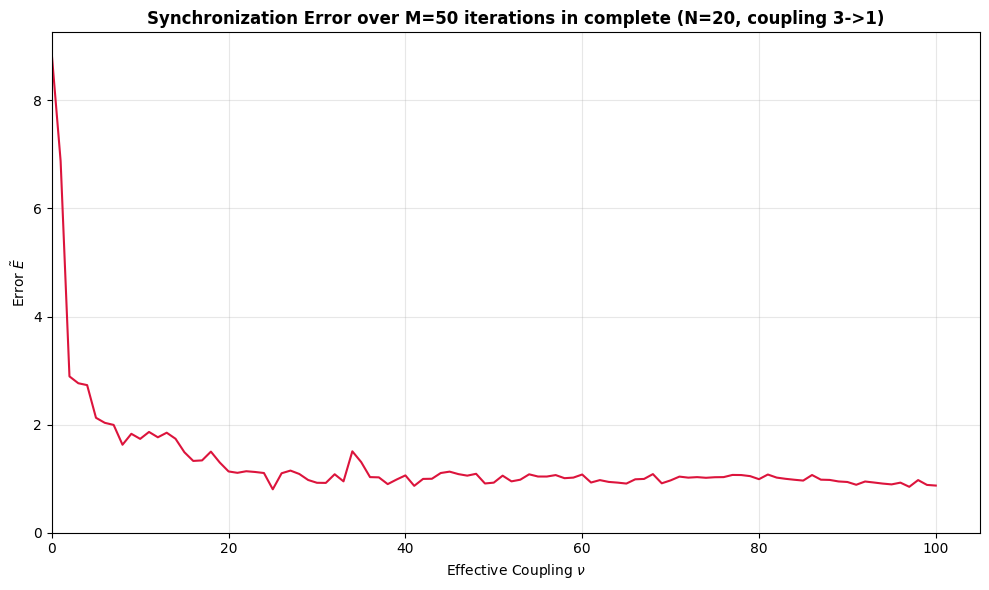

In [32]:
i = 1
j = 3
N = 20
x0 = in_lorenz

# The zeros are []
important_nus = [0.0]

network_model = 'complete'
G = create_graph('complete', N)
L = nx.laplacian_matrix(G).toarray().astype(float)
theory_complete = analyze_network_synchronizability(L, i=i, j=j)
print(theory_complete)

# generate_data(x0=x0, L=L, network_model=network_model, i=i, j=j, M=0, important_nus=important_nus, T=50.0, t_save_start=5.0, save_every=0.05, dt=0.001, eps=1e-8)

average_errors = load_and_plot_robust_results(L=L, network_model=network_model, N=N, i=i, j=j)

### class II (1 -> 1)

N=20

{'class': 'II', 'synchronizable': True, 'nu_min': 7.8115, 'alpha_min': 0.3905750000000003, 'lambda2': 19.999999999999986, 'lambda_n': 20.000000000000025, 'eigenratio': 1.000000000000002}


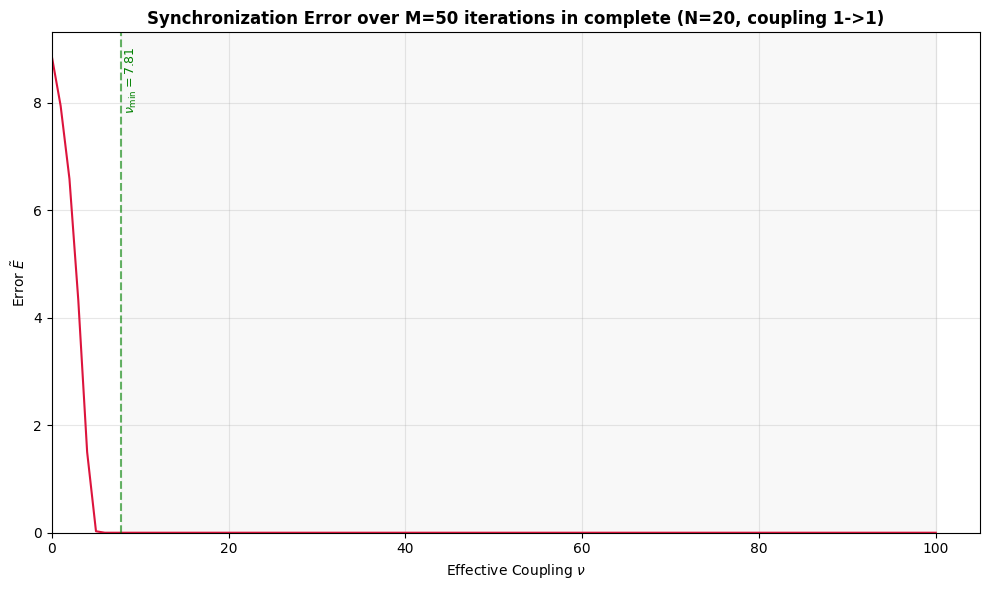

In [33]:
i = 1
j = 1
N = 20
x0 = in_lorenz

# The zeros are [7.8115]
important_nus = [0.0, 7.0, 9.0]

network_model = 'complete'
G = create_graph('complete', N)
L = nx.laplacian_matrix(G).toarray().astype(float)
theory_complete = analyze_network_synchronizability(L, i=i, j=j)
print(theory_complete)

# generate_data(x0=x0, L=L, network_model=network_model, i=i, j=j, M=0, important_nus=important_nus, T=50.0, t_save_start=5.0, save_every=0.05, dt=0.001, eps=1e-8)

average_errors = load_and_plot_robust_results(L=L, network_model=network_model, N=N, i=i, j=j)

### class III (2 -> 1)

N=20

{'class': 'III', 'synchronizable': True, 'nu_min': 3.9626, 'nu_max': 23.6467, 'msf_ratio': 5.9674708524705995, 'alpha_min': 0.19813000000000014, 'alpha_max': 1.1823349999999986, 'lambda2': 19.999999999999986, 'lambda_n': 20.000000000000025, 'eigenratio': 1.000000000000002}


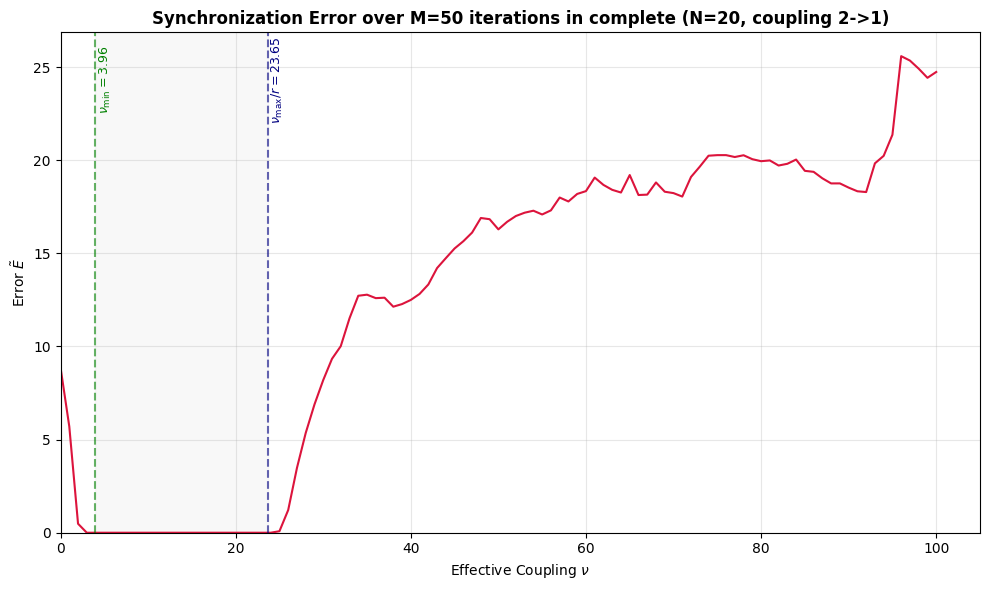

In [34]:
i = 1
j = 2
N = 20
x0 = in_lorenz

# The zeros are [3.9626, 23.6467]
important_nus = [0.0, 3.0, 5.0, 23.0, 25.0]

network_model = 'complete'
G = create_graph('complete', N)
L = nx.laplacian_matrix(G).toarray().astype(float)
theory_complete = analyze_network_synchronizability(L, i=i, j=j)
print(theory_complete)

# generate_data(x0=x0, L=L, network_model=network_model, i=i, j=j, M=0, important_nus=important_nus, T=50.0, t_save_start=5.0, save_every=0.05, dt=0.001, eps=1e-8)

average_errors = load_and_plot_robust_results(L=L, network_model=network_model, N=N, i=i, j=j)

## Regular Ring Lattice ('ring')

### class I (3 -> 1)

N=20

{'class': 'I', 'synchronizable': False, 'lambda2': 0.47985297865979787, 'lambda_n': 6.2360679774998, 'eigenratio': 12.995788824562021}


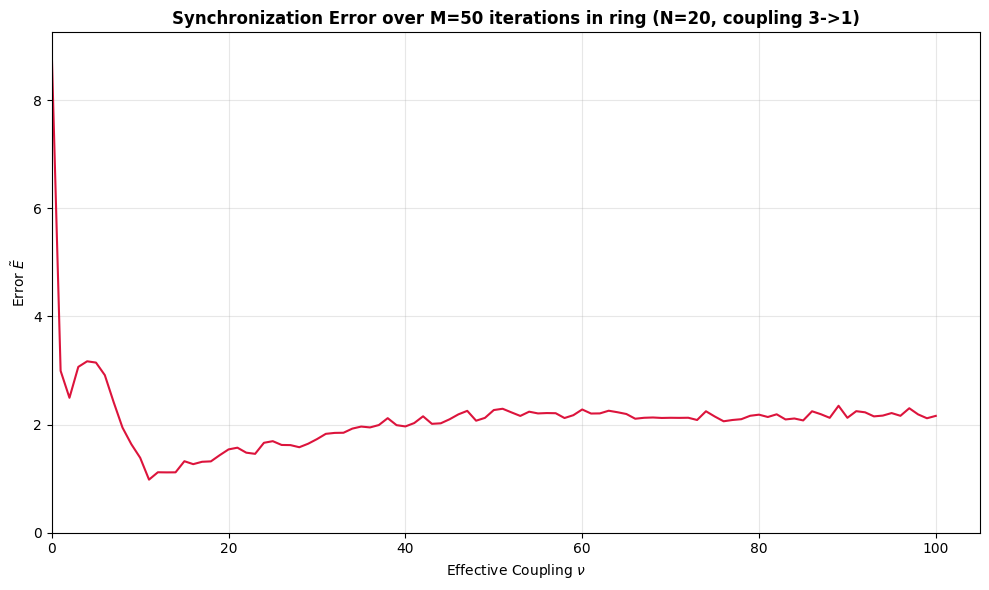

In [35]:
i = 1
j = 3
N = 20
x0 = in_lorenz

# The zeros are []
important_nus = [0.0]

network_model = 'ring'
G = create_graph('ring', N, k=4)
L = nx.laplacian_matrix(G).toarray().astype(float)
theory_complete = analyze_network_synchronizability(L, i=i, j=j)
print(theory_complete)

# generate_data(x0=x0, L=L, network_model=network_model, i=i, j=j, M=0, important_nus=important_nus, T=50.0, t_save_start=5.0, save_every=0.05, dt=0.001, eps=1e-8)

average_errors = load_and_plot_robust_results(L=L, network_model=network_model, N=N, i=i, j=j)

### class II (1 -> 1)

N=20

{'class': 'II', 'synchronizable': True, 'nu_min': 7.8115, 'alpha_min': 16.2789444838231, 'lambda2': 0.47985297865979787, 'lambda_n': 6.2360679774998, 'eigenratio': 12.995788824562021}


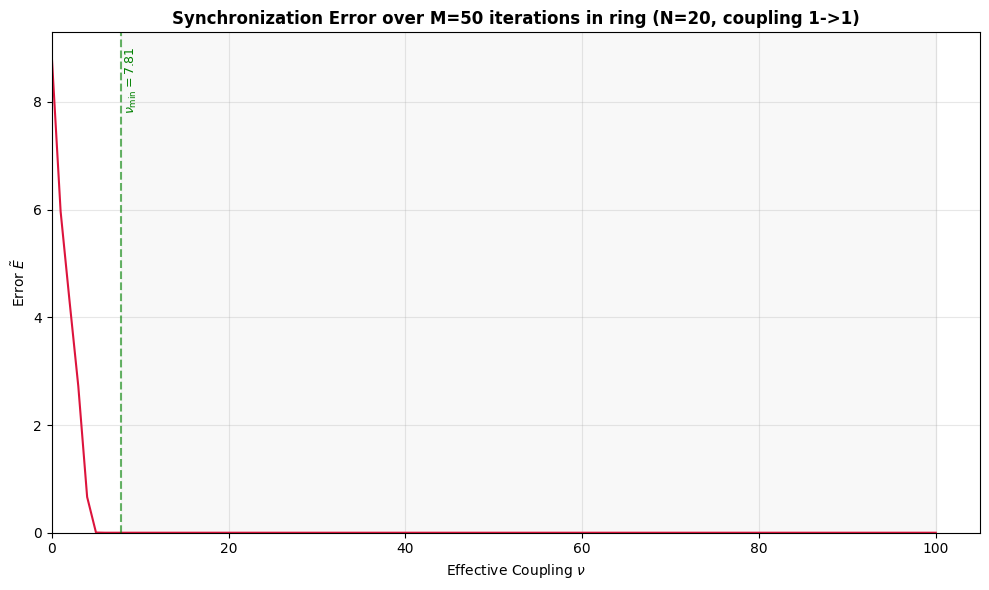

In [36]:
i = 1
j = 1
N = 20
x0 = in_lorenz

# The zeros are [7.8115]
important_nus = [0.0, 7.0, 9.0]

network_model = 'ring'
G = create_graph('ring', N, k=4)
L = nx.laplacian_matrix(G).toarray().astype(float)
theory_complete = analyze_network_synchronizability(L, i=i, j=j)
print(theory_complete)

# generate_data(x0=x0, L=L, network_model=network_model, i=i, j=j, M=0, important_nus=important_nus, T=50.0, t_save_start=5.0, save_every=0.05, dt=0.001, eps=1e-8)

average_errors = load_and_plot_robust_results(L=L, network_model=network_model, N=N, i=i, j=j)

### class III (2 -> 1)

N=20

{'class': 'III', 'synchronizable': False, 'nu_min': 3.9626, 'nu_max': 23.6467, 'msf_ratio': 5.9674708524705995, 'lambda2': 0.47985297865979787, 'lambda_n': 6.2360679774998, 'eigenratio': 12.995788824562021}


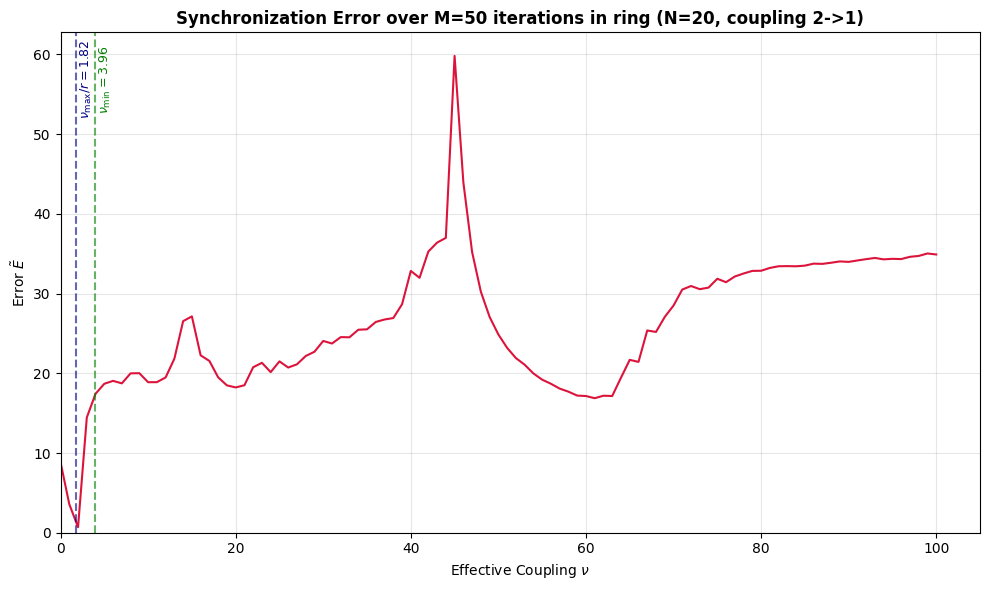

In [37]:
i = 1
j = 2
N = 20
x0 = in_lorenz

# The zeros are [3.9626, 23.6467]
important_nus = [0.0, 3.0, 5.0, 23.0, 25.0]

network_model = 'ring'
G = create_graph('ring', N, k=4)
L = nx.laplacian_matrix(G).toarray().astype(float)
theory_complete = analyze_network_synchronizability(L, i=i, j=j)
print(theory_complete)

# generate_data(x0=x0, L=L, network_model=network_model, i=i, j=j, M=0, important_nus=important_nus, T=50.0, t_save_start=5.0, save_every=0.05, dt=0.001, eps=1e-8)

average_errors = load_and_plot_robust_results(L=L, network_model=network_model, N=N, i=i, j=j)

## Erdős-Rényi ('ER')

### class I (3 -> 1)

N=20

{'class': 'I', 'synchronizable': False, 'lambda2': 2.650655894046017, 'lambda_n': 13.597940590064887, 'eigenratio': 5.130028616920434}


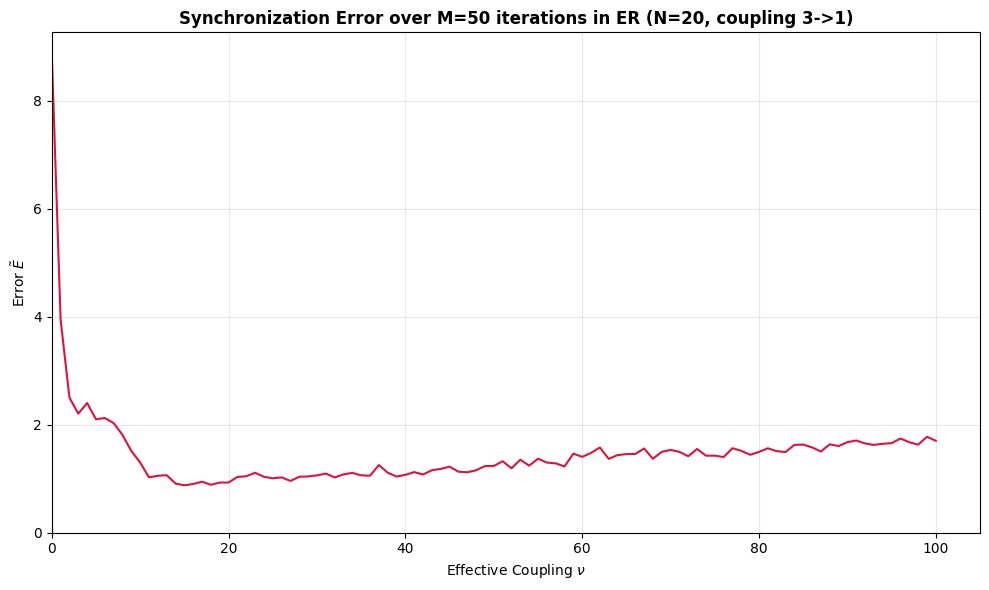

In [38]:
i = 1
j = 3
N = 20
x0 = in_lorenz

# The zeros are []
important_nus = [0.0]

network_model = 'ER'
G = create_graph('ER', N, p=0.4)
L = nx.laplacian_matrix(G).toarray().astype(float)
theory_complete = analyze_network_synchronizability(L, i=i, j=j)
print(theory_complete)

# generate_data(x0=x0, L=L, network_model=network_model, i=i, j=j, M=0, important_nus=important_nus, T=50.0, t_save_start=5.0, save_every=0.05, dt=0.001, eps=1e-8)

average_errors = load_and_plot_robust_results(L=L, network_model=network_model, N=N, i=i, j=j)

### class II (1 -> 1)

N=20

{'class': 'II', 'synchronizable': True, 'nu_min': 7.8115, 'alpha_min': 2.3872960932691187, 'lambda2': 3.2721119185945122, 'lambda_n': 12.241818006146858, 'eigenratio': 3.7412589516208086}


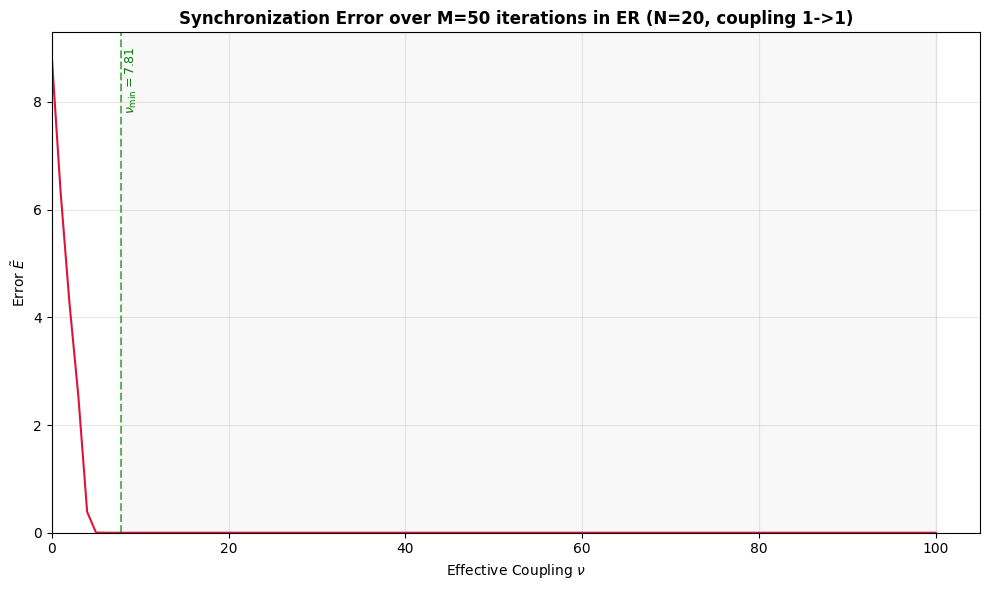

In [39]:
i = 1
j = 1
N = 20
x0 = in_lorenz

# The zeros are [7.8115]
important_nus = [0.0, 7.0, 9.0]

network_model = 'ER'
G = create_graph('ER', N, p=0.4)
L = nx.laplacian_matrix(G).toarray().astype(float)
theory_complete = analyze_network_synchronizability(L, i=i, j=j)
print(theory_complete)

# generate_data(x0=x0, L=L, network_model=network_model, i=i, j=j, M=0, important_nus=important_nus, T=50.0, t_save_start=5.0, save_every=0.05, dt=0.001, eps=1e-8)

average_errors = load_and_plot_robust_results(L=L, network_model=network_model, N=N, i=i, j=j)

### class III (2 -> 1)

N=20

{'class': 'III', 'synchronizable': True, 'nu_min': 3.9626, 'nu_max': 23.6467, 'msf_ratio': 5.9674708524705995, 'alpha_min': 1.3760037868780706, 'alpha_max': 1.7474826501594953, 'lambda2': 2.8797885861858687, 'lambda_n': 13.531865393823354, 'eigenratio': 4.698909308389756}


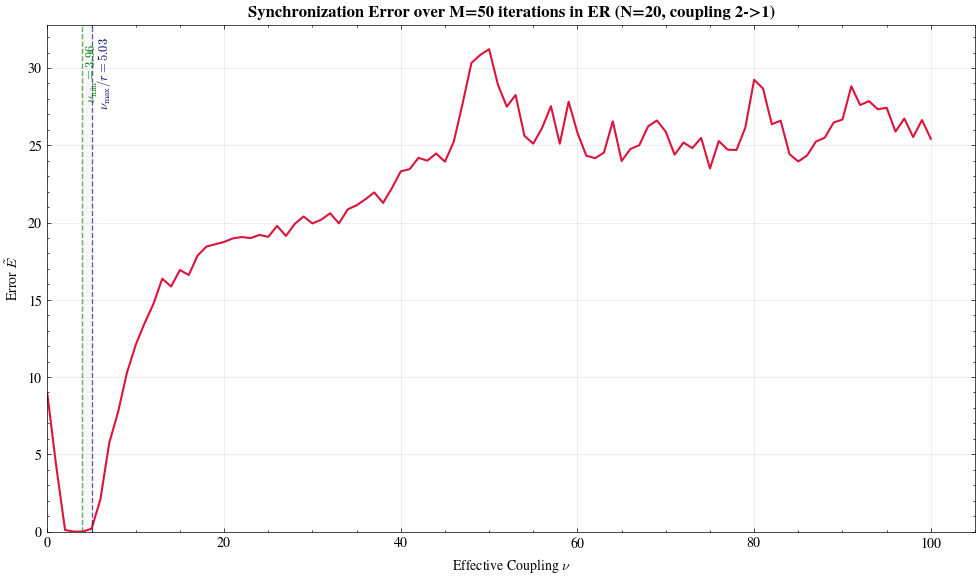

In [176]:
i = 1
j = 2
N = 20
x0 = in_lorenz

# The zeros are [3.9626, 23.6467]
important_nus = [0.0, 3.0, 5.0, 23.0, 25.0]

network_model = 'ER'
G = create_graph('ER', N, p=0.4)
L = nx.laplacian_matrix(G).toarray().astype(float)
theory_complete = analyze_network_synchronizability(L, i=i, j=j)
print(theory_complete)

# generate_data(x0=x0, L=L, network_model=network_model, i=i, j=j, M=0, important_nus=important_nus, T=50.0, t_save_start=5.0, save_every=0.05, dt=0.001, eps=1e-8)

average_errors = load_and_plot_robust_results(L=L, network_model=network_model, N=N, i=i, j=j)

## Watts-Strogatz ('WS')

### class I (3 -> 1)

N=20

{'class': 'I', 'synchronizable': False, 'lambda2': 3.24802456576354, 'lambda_n': 12.414789711998338, 'eigenratio': 3.8222585638233593}


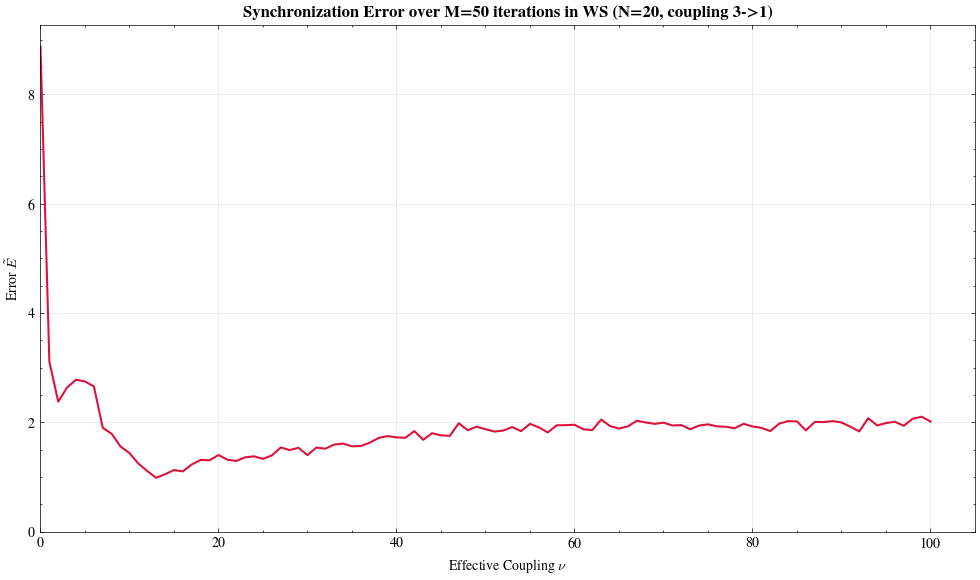

In [177]:
i = 1
j = 3
N = 20
x0 = in_lorenz

# The zeros are []
important_nus = [0.0]

network_model = 'WS'
G = create_graph('WS', N, k=8, p=0.1)
L = nx.laplacian_matrix(G).toarray().astype(float)
theory_complete = analyze_network_synchronizability(L, i=i, j=j)
print(theory_complete)

# generate_data(x0=x0, L=L, network_model=network_model, i=i, j=j, M=0, important_nus=important_nus, T=50.0, t_save_start=5.0, save_every=0.05, dt=0.001, eps=1e-8)

average_errors = load_and_plot_robust_results(L=L, network_model=network_model, N=N, i=i, j=j)

### class II (1 -> 1)

N=20

{'class': 'II', 'synchronizable': True, 'nu_min': 7.8115, 'alpha_min': 2.5143886600261, 'lambda2': 3.106719388369702, 'lambda_n': 11.946653647202503, 'eigenratio': 3.84542411262695}


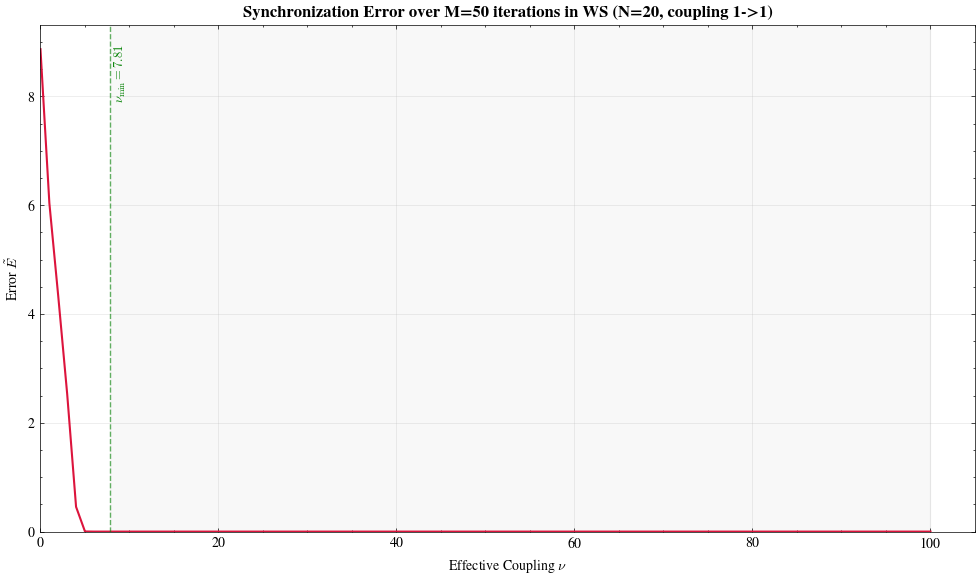

In [178]:
i = 1
j = 1
N = 20
x0 = in_lorenz

# The zeros are [7.8115]
important_nus = [0.0, 7.0, 9.0]

network_model = 'WS'
G = create_graph('WS', N, k=8, p=0.1)
L = nx.laplacian_matrix(G).toarray().astype(float)
theory_complete = analyze_network_synchronizability(L, i=i, j=j)
print(theory_complete)

# generate_data(x0=x0, L=L, network_model=network_model, i=i, j=j, M=0, important_nus=important_nus, T=50.0, t_save_start=5.0, save_every=0.05, dt=0.001, eps=1e-8)

average_errors = load_and_plot_robust_results(L=L, network_model=network_model, N=N, i=i, j=j)

### class III (2 -> 1)

N=20

{'class': 'III', 'synchronizable': True, 'nu_min': 3.9626, 'nu_max': 23.6467, 'msf_ratio': 5.9674708524705995, 'alpha_min': 1.4379712878744317, 'alpha_max': 1.9932167615996115, 'lambda2': 2.755687845379307, 'lambda_n': 11.863586768667783, 'eigenratio': 4.305127225698097}


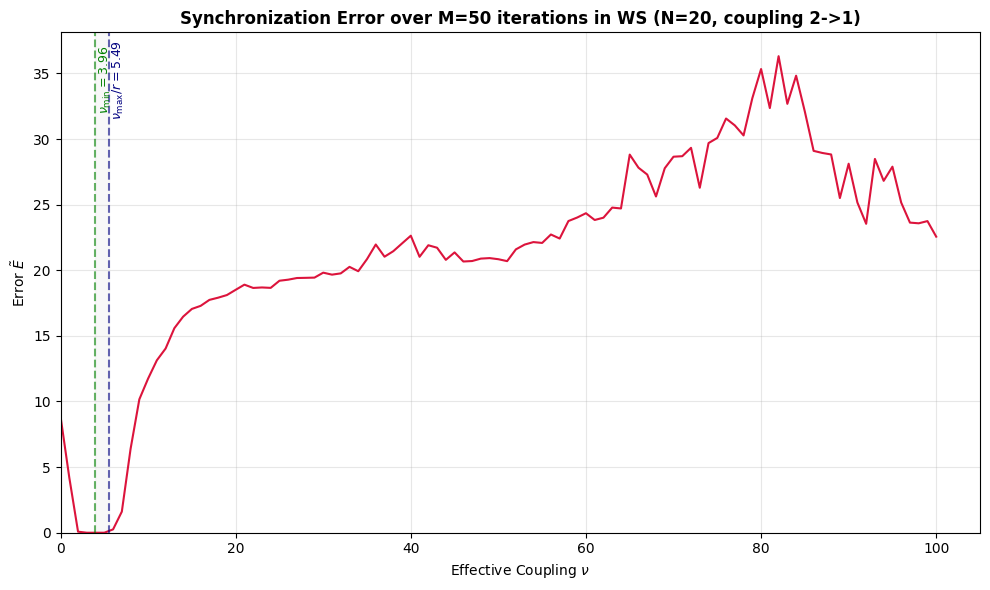

In [43]:
i = 1
j = 2
N = 20
x0 = in_lorenz

# The zeros are [3.9626, 23.6467]
important_nus = [0.0, 3.0, 5.0, 23.0, 25.0]

network_model = 'WS'
G = create_graph('WS', N, k=8, p=0.1)
L = nx.laplacian_matrix(G).toarray().astype(float)
theory_complete = analyze_network_synchronizability(L, i=i, j=j)
print(theory_complete)

# generate_data(x0=x0, L=L, network_model=network_model, i=i, j=j, M=0, important_nus=important_nus, T=50.0, t_save_start=5.0, save_every=0.05, dt=0.001, eps=1e-8)

average_errors = load_and_plot_robust_results(L=L, network_model=network_model, N=N, i=i, j=j)

## Barabási-Albert ('BA')

### class I (3 -> 1)

N=20

{'class': 'I', 'synchronizable': False, 'lambda2': 0.9480579173316841, 'lambda_n': 11.322774415038591, 'eigenratio': 11.943125212124826}


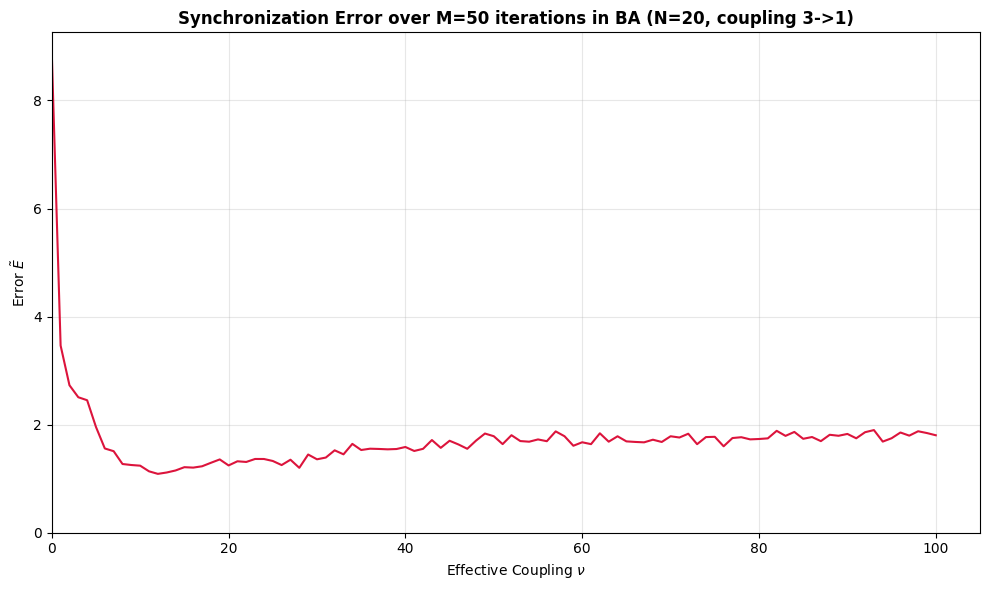

In [44]:
i = 1
j = 3
N = 20
x0 = in_lorenz

# The zeros are []
important_nus = [0.0]

network_model = 'BA'
G = create_graph('BA', N, m=2)
L = nx.laplacian_matrix(G).toarray().astype(float)
theory_complete = analyze_network_synchronizability(L, i=i, j=j)
print(theory_complete)

# generate_data(x0=x0, L=L, network_model=network_model, i=i, j=j, M=0, important_nus=important_nus, T=50.0, t_save_start=5.0, save_every=0.05, dt=0.001, eps=1e-8)

average_errors = load_and_plot_robust_results(L=L, network_model=network_model, N=N, i=i, j=j)

### class II (1 -> 1)

N=20

{'class': 'II', 'synchronizable': True, 'nu_min': 7.8115, 'alpha_min': 8.857948547285613, 'lambda2': 0.8818633296750993, 'lambda_n': 12.277024627973077, 'eigenratio': 13.921686291793359}


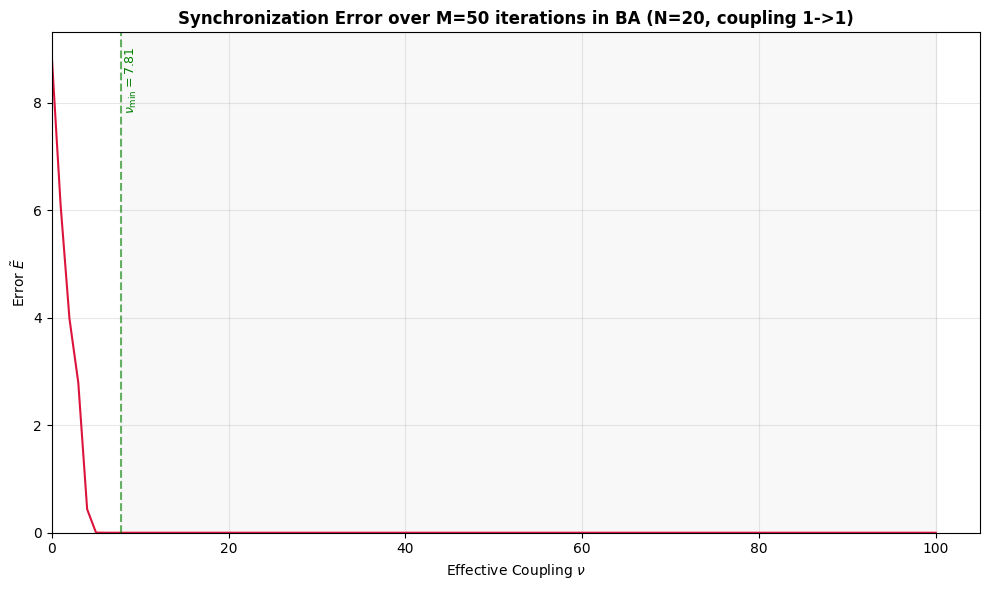

In [45]:
i = 1
j = 1
N = 20
x0 = in_lorenz

# The zeros are [7.8115]
important_nus = [0.0, 7.0, 9.0]

network_model = 'BA'
G = create_graph('BA', N, m=2)
L = nx.laplacian_matrix(G).toarray().astype(float)
theory_complete = analyze_network_synchronizability(L, i=i, j=j)
print(theory_complete)

generate_data(x0=x0, L=L, network_model=network_model, i=i, j=j, M=0, important_nus=important_nus, T=50.0, t_save_start=5.0, save_every=0.05, dt=0.001, eps=1e-8)

average_errors = load_and_plot_robust_results(L=L, network_model=network_model, N=N, i=i, j=j)

### class III (2 -> 1)

N=20

{'class': 'III', 'synchronizable': False, 'nu_min': 3.9626, 'nu_max': 23.6467, 'msf_ratio': 5.9674708524705995, 'lambda2': 0.7037417766765964, 'lambda_n': 8.941684144479478, 'eigenratio': 12.705916347195366}


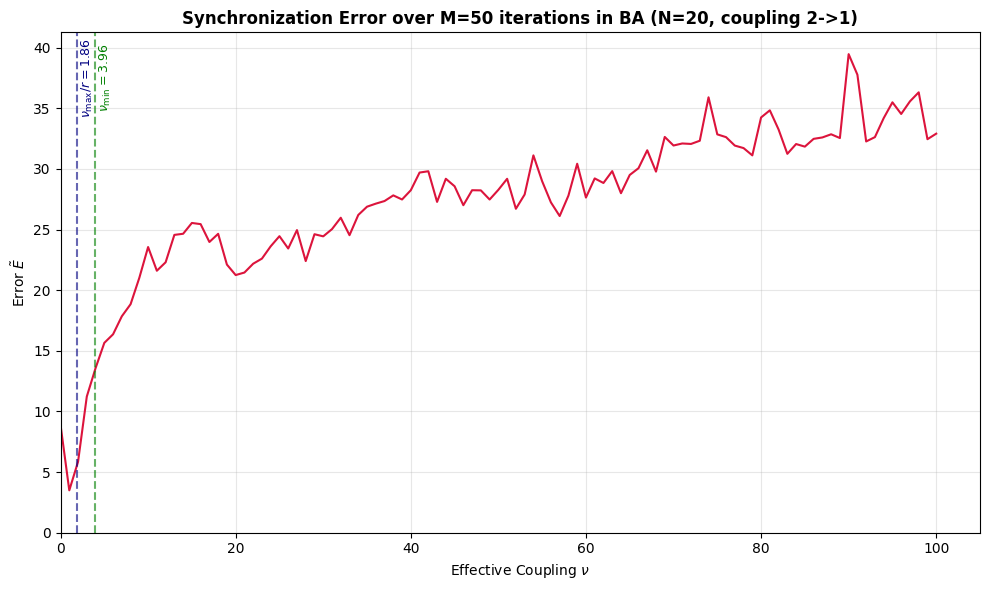

In [46]:
i = 1
j = 2
N = 20
x0 = in_lorenz

# The zeros are [3.9626, 23.6467]
important_nus = [0.0, 3.0, 5.0, 23.0, 25.0]

network_model = 'BA'
G = create_graph('BA', N, m=2)
L = nx.laplacian_matrix(G).toarray().astype(float)
theory_complete = analyze_network_synchronizability(L, i=i, j=j)
print(theory_complete)

# generate_data(x0=x0, L=L, network_model=network_model, i=i, j=j, M=0, important_nus=important_nus, T=50.0, t_save_start=5.0, save_every=0.05, dt=0.001, eps=1e-8)

average_errors = load_and_plot_robust_results(L=L, network_model=network_model, N=N, i=i, j=j)